
# Final dissertation results — combined V3 + Exact geodesic-loss V4

This notebook **does not train, retune, or re-evaluate any model**. It only reads the already-saved per-seed test-evaluation JSON files from Google Drive and consolidates them into one final result set.

The four displayed models are deliberately sourced as follows:

- **Exact** → `final_v4_50k_cosine_geodesic_loss`
- **Partial (graph)** → `final_v3_50k_cosine`
- **Full (graph)** → `final_v3_50k_cosine`
- **Euclidean** → `final_v3_50k_cosine`

Therefore the old V3 Exact results are **intentionally ignored**. This prevents accidentally mixing the old Exact final procedure with the new geodesic-loss Exact experiment.

For each test metric, the saved evaluation first averages over the fixed test-noise batches within a trained seed. This notebook then reports **mean ± sample SD across the five independently trained final seeds (101–105)**, matching the convention used in the Exact-geodesic table.


In [19]:

# ============================================================
# 1. Imports, Drive mount, and source protocol
# ============================================================

from pathlib import Path
import json
import os
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

IN_COLAB = (
    "google.colab" in sys.modules
    or os.environ.get("COLAB_GPU") is not None
    or os.environ.get("COLAB_TPU_ADDR") is not None
)

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive")
else:
    # Local use:
    # export DISSERTATION_DRIVE_ROOT=/path/to/your/GoogleDrive/MyDrive
    DRIVE_ROOT = Path(
        os.environ.get("DISSERTATION_DRIVE_ROOT", Path.cwd())
    )

RESULTS_ROOT = (
    DRIVE_ROOT
    / "dissertation"
    / "final_four_model_all_manifolds_v1"
)

COMBINED_DIR = RESULTS_ROOT / "final_combined_v3_plus_v4_exact_geodesic"
FIGURE_DIR = COMBINED_DIR / "figures"
COMBINED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_SEEDS = (101, 102, 103, 104, 105)

# IMPORTANT: Exact comes ONLY from V4 geodesic-loss.
SOURCE_RUNS = {
    "exact": {
        "run_dir": "final_v4_50k_cosine_geodesic_loss",
        "method_label": "Exact (geodesic loss)",
        "protocol_label": "V4 exact, 50k cosine, geodesic fixed-point loss",
    },
    "partial": {
        "run_dir": "final_v3_50k_cosine",
        "method_label": "Partial (graph)",
        "protocol_label": "V3, 50k cosine",
    },
    "full": {
        "run_dir": "final_v3_50k_cosine",
        "method_label": "Full (graph)",
        "protocol_label": "V3, 50k cosine",
    },
    "euclidean": {
        "run_dir": "final_v3_50k_cosine",
        "method_label": "Euclidean",
        "protocol_label": "V3, 50k cosine",
    },
}

METHOD_ORDER = ["exact", "partial", "full", "euclidean"]
MANIFOLD_ORDER = ["sphere", "torus", "so3"]

print("Results root:", RESULTS_ROOT)
print("Combined outputs:", COMBINED_DIR)
print("\nLocked source protocol:")
for method in METHOD_ORDER:
    cfg = SOURCE_RUNS[method]
    print(f"  {cfg['method_label']:<24} <- {cfg['run_dir']}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results root: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1
Combined outputs: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic

Locked source protocol:
  Exact (geodesic loss)    <- final_v4_50k_cosine_geodesic_loss
  Partial (graph)          <- final_v3_50k_cosine
  Full (graph)             <- final_v3_50k_cosine
  Euclidean                <- final_v3_50k_cosine



## 2. Load the cached per-seed test evaluations

The loader only reads files named `seed_<seed>_test_evaluation.json`. It does not import the training notebook and does not load model weights.

The directory pattern is

```text
RESULTS_ROOT / manifold / dataset / method / run_dir / seed_<seed>_test_evaluation.json
```

For each seed we retain the best validation checkpoint metadata and every test metric stored under `evaluation["summary"]`.


In [20]:

# ============================================================
# 2. Scan the two final-result protocols
# ============================================================

def _seed_from_filename(path: Path) -> int:
    m = re.fullmatch(r"seed_(\d+)_test_evaluation\.json", path.name)
    if m is None:
        raise ValueError(f"Unexpected test-evaluation filename: {path.name}")
    return int(m.group(1))


def load_combined_cached_results():
    run_rows = []
    metric_rows = []

    for method in METHOD_ORDER:
        cfg = SOURCE_RUNS[method]
        run_dir = cfg["run_dir"]

        pattern = f"*/*/{method}/{run_dir}/seed_*_test_evaluation.json"
        paths = sorted(RESULTS_ROOT.glob(pattern))

        print(
            f"{cfg['method_label']:<24}: "
            f"{len(paths):>3} cached seed evaluations"
        )

        for path in paths:
            seed = _seed_from_filename(path)
            manifold = path.parents[3].name
            dataset = path.parents[2].name
            method_from_path = path.parents[1].name

            if method_from_path != method:
                raise RuntimeError(
                    f"Method/path mismatch: expected {method}, found {method_from_path}"
                )

            with open(path, "r") as f:
                ev = json.load(f)

            summary = ev.get("summary", {})
            if not summary:
                warnings.warn(f"No summary metrics in {path}")
                continue

            checkpoint = path.parent / f"seed_{seed}.pt"

            run_rows.append({
                "manifold": manifold,
                "dataset": dataset,
                "method": method,
                "method_label": cfg["method_label"],
                "source_protocol": cfg["protocol_label"],
                "source_run_dir": run_dir,
                "seed": seed,
                "best_step": ev.get("_best_validation_step", np.nan),
                "best_validation_score": ev.get("_best_validation_score", np.nan),
                "checkpoint_exists": checkpoint.exists(),
                "test_json": str(path),
                "checkpoint": str(checkpoint),
            })

            for metric, vals in summary.items():
                if "mean" not in vals:
                    warnings.warn(
                        f"{path}: metric {metric!r} has no saved mean; skipping"
                    )
                    continue

                metric_rows.append({
                    "manifold": manifold,
                    "dataset": dataset,
                    "method": method,
                    "method_label": cfg["method_label"],
                    "source_protocol": cfg["protocol_label"],
                    "source_run_dir": run_dir,
                    "seed": seed,
                    "metric": metric,
                    # This is already the average across the fixed
                    # test-noise batches for this trained seed.
                    "value": float(vals["mean"]),
                    "sd_over_test_noise_batches": float(
                        vals.get("std_noise", np.nan)
                    ),
                })

    runs = pd.DataFrame(run_rows)
    metrics = pd.DataFrame(metric_rows)

    if runs.empty or metrics.empty:
        raise FileNotFoundError(
            "No cached final test evaluations were found. "
            "Check RESULTS_ROOT and the run-directory names above."
        )

    # A duplicate here would silently double-weight a training seed.
    duplicate_keys = (
        runs.groupby(["manifold", "dataset", "method", "seed"])
        .size()
        .reset_index(name="n")
    )
    duplicate_keys = duplicate_keys[duplicate_keys["n"] != 1]

    if not duplicate_keys.empty:
        display(duplicate_keys)
        raise RuntimeError(
            "Duplicate cached evaluations detected for the same "
            "manifold/dataset/method/seed."
        )

    return runs, metrics


COMBINED_RUNS, COMBINED_TEST_BY_SEED = load_combined_cached_results()

print(
    "\nUnique completed dataset-method-seed runs:",
    len(COMBINED_RUNS),
)
print(
    "Unique datasets:",
    COMBINED_RUNS[["manifold", "dataset"]]
    .drop_duplicates()
    .shape[0],
)


Exact (geodesic loss)   :  75 cached seed evaluations
Partial (graph)         :  75 cached seed evaluations
Full (graph)            :  75 cached seed evaluations
Euclidean               :  75 cached seed evaluations

Unique completed dataset-method-seed runs: 300
Unique datasets: 15



## 3. Completion audit

This is deliberately strict. A final dissertation table should not quietly average 3 or 4 seeds for one method while using 5 for another.

The audit reports exactly which seeds are present for every dataset–method combination. If any combination does not contain seeds **101–105**, the notebook stops before constructing the final table.

If you are using this notebook while jobs are still running, temporarily set `REQUIRE_COMPLETE_FIVE_SEEDS = False`.


In [3]:

# ============================================================
# 3. Five-seed completion audit
# ============================================================

REQUIRE_COMPLETE_FIVE_SEEDS = True

dataset_keys = (
    COMBINED_RUNS[["manifold", "dataset"]]
    .drop_duplicates()
    .sort_values(["manifold", "dataset"])
    .reset_index(drop=True)
)

audit_rows = []

for _, drow in dataset_keys.iterrows():
    manifold = drow["manifold"]
    dataset = drow["dataset"]

    for method in METHOD_ORDER:
        sub = COMBINED_RUNS[
            (COMBINED_RUNS["manifold"] == manifold)
            & (COMBINED_RUNS["dataset"] == dataset)
            & (COMBINED_RUNS["method"] == method)
        ]

        present = tuple(sorted(set(sub["seed"].astype(int))))
        missing = tuple(s for s in EXPECTED_SEEDS if s not in present)
        unexpected = tuple(s for s in present if s not in EXPECTED_SEEDS)

        audit_rows.append({
            "manifold": manifold,
            "dataset": dataset,
            "method": method,
            "method_label": SOURCE_RUNS[method]["method_label"],
            "source_run_dir": SOURCE_RUNS[method]["run_dir"],
            "n_tested": len(present),
            "present_seeds": present,
            "missing_seeds": missing,
            "unexpected_seeds": unexpected,
            "all_checkpoints_present": (
                bool(sub["checkpoint_exists"].all())
                if len(sub)
                else False
            ),
            "complete": (
                present == EXPECTED_SEEDS
                and len(unexpected) == 0
            ),
        })

COMPLETION_AUDIT = pd.DataFrame(audit_rows)

# Human-readable ordering.
COMPLETION_AUDIT["_manifold_order"] = (
    COMPLETION_AUDIT["manifold"]
    .map({m: i for i, m in enumerate(MANIFOLD_ORDER)})
    .fillna(len(MANIFOLD_ORDER))
)
COMPLETION_AUDIT["_method_order"] = (
    COMPLETION_AUDIT["method"]
    .map({m: i for i, m in enumerate(METHOD_ORDER)})
)

COMPLETION_AUDIT = (
    COMPLETION_AUDIT
    .sort_values(
        ["_manifold_order", "dataset", "_method_order"]
    )
    .drop(columns=["_manifold_order", "_method_order"])
    .reset_index(drop=True)
)

display(COMPLETION_AUDIT)

COMPLETION_AUDIT.to_csv(
    COMBINED_DIR / "completion_audit.csv",
    index=False,
)

incomplete = COMPLETION_AUDIT[~COMPLETION_AUDIT["complete"]]

print(
    f"\nComplete dataset-method cells: "
    f"{len(COMPLETION_AUDIT) - len(incomplete)}/{len(COMPLETION_AUDIT)}"
)

if REQUIRE_COMPLETE_FIVE_SEEDS and not incomplete.empty:
    display(
        incomplete[
            [
                "manifold",
                "dataset",
                "method_label",
                "n_tested",
                "present_seeds",
                "missing_seeds",
            ]
        ]
    )
    raise RuntimeError(
        "Final result consolidation stopped because at least one "
        "dataset-method combination does not contain all five expected seeds."
    )


,manifold,dataset,method,method_label,source_run_dir,n_tested,present_seeds,missing_seeds,unexpected_seeds,all_checkpoints_present,complete
0,sphere,earthquake,exact,Exact (geodesic loss),final_v4_50k_cosine_geodesic_loss,5,"(101, 102, 103, 104, 105)",(),(),True,True
1,sphere,earthquake,partial,Partial (graph),final_v3_50k_cosine,5,"(101, 102, 103, 104, 105)",(),(),True,True
2,sphere,earthquake,full,Full (graph),final_v3_50k_cosine,5,"(101, 102, 103, 104, 105)",(),(),True,True
3,sphere,earthquake,euclidean,Euclidean,final_v3_50k_cosine,5,"(101, 102, 103, 104, 105)",(),(),True,True
4,sphere,fire,exact,Exact (geodesic loss),final_v4_50k_cosine_geodesic_loss,5,"(101, 102, 103, 104, 105)",(),(),True,True
5,sphere,fire,partial,Partial (graph),final_v3_50k_cosine,5,"(101, 102, 103, 104, 105)",(),(),True,True
6,sphere,fire,full,Full (graph),final_v3_50k_cosine,5,"(101, 102, 103, 104, 105)",(),(),True,True
7,sphere,fire,euclidean,Euclidean,final_v3_50k_cosine,5,"(101, 102, 103, 104, 105)",(),(),True,True
8,sphere,flood,exact,Exact (geodesic loss),final_v4_50k_cosine_geodesic_loss,5,"(101, 102, 103, 104, 105)",(),(),True,True
9,sphere,flood,partial,Partial (graph),final_v3_50k_cosine,5,"(101, 102, 103, 104, 105)",(),(),True,True



Complete dataset-method cells: 60/60



## 4. Final combined result table

The aggregation below is the statistically appropriate level for the final comparison:

1. each saved seed value is already the mean over the fixed test-noise batches;
2. those five seed-level values are treated as the five independently trained final models;
3. the table reports their **mean ± sample SD**.

The table deliberately keeps manifold-specific diagnostics as `NaN` when they are not applicable, just like the Exact-geodesic result table.


In [4]:

# ============================================================
# 4. Aggregate across independently trained final seeds
# ============================================================

COMBINED_TEST_LONG = (
    COMBINED_TEST_BY_SEED
    .groupby(
        [
            "manifold",
            "dataset",
            "method",
            "method_label",
            "metric",
        ],
        as_index=False,
    )
    .agg(
        mean_over_training_seeds=("value", "mean"),
        sd_over_training_seeds=(
            "value",
            lambda x: (
                float(x.std(ddof=1))
                if len(x) > 1
                else np.nan
            ),
        ),
        n_training_seeds=("seed", "nunique"),
    )
)

# A JSON can exist while one metric is accidentally absent inside it.
# Do not silently compute a final metric from fewer than five trained seeds.
metric_seed_audit = COMBINED_TEST_LONG[
    COMBINED_TEST_LONG["n_training_seeds"] != len(EXPECTED_SEEDS)
]

if REQUIRE_COMPLETE_FIVE_SEEDS and not metric_seed_audit.empty:
    display(metric_seed_audit)
    raise RuntimeError(
        "At least one saved test metric is not present for all five "
        "independently trained final seeds."
    )

FRIENDLY_METRIC_NAMES = {
    "tile_accuracy_projected":
        "Checkerboard tile accuracy ↑",

    "intrinsic_discrepancy_sq_projected":
        "Intrinsic discrepancy² ↓",

    "ambient_mmd_sq_projected":
        "Projected ambient MMD² ↓",

    "projection_gain_ambient_mmd_sq":
        "Projection gain",

    "ambient_mmd_sq_raw":
        "Raw ambient MMD² ↓",

    "so3_det_abs_error_mean":
        "SO(3) det error ↓",

    "so3_orthogonality_mean":
        "SO(3) orthogonality error ↓",

    "support_mean":
        "Support mean ↓",

    "support_median":
        "Support median ↓",

    "support_p95":
        "Support p95 ↓",

    "so3_det_abs_error_p95":
        "SO(3) det error p95 ↓",

    "so3_orthogonality_p95":
        "SO(3) orthogonality p95 ↓",
}

DISPLAY_METRIC_ORDER = [
    "Checkerboard tile accuracy ↑",
    "Intrinsic discrepancy² ↓",
    "Projected ambient MMD² ↓",
    "Projection gain",
    "Raw ambient MMD² ↓",
    "SO(3) det error ↓",
    "SO(3) orthogonality error ↓",
    "Support mean ↓",
    "Support median ↓",
    "Support p95 ↓",
    "SO(3) det error p95 ↓",
    "SO(3) orthogonality p95 ↓",
]

fmt = COMBINED_TEST_LONG.copy()
fmt["display_metric"] = (
    fmt["metric"]
    .map(FRIENDLY_METRIC_NAMES)
    .fillna(fmt["metric"])
)

fmt["mean ± sd"] = fmt.apply(
    lambda r: (
        f"{r['mean_over_training_seeds']:.6g} "
        f"± {r['sd_over_training_seeds']:.3g}"
        if np.isfinite(r["sd_over_training_seeds"])
        else f"{r['mean_over_training_seeds']:.6g}"
    ),
    axis=1,
)

FINAL_TEST_TABLE = (
    fmt
    .pivot_table(
        index=[
            "manifold",
            "dataset",
            "method",
            "method_label",
        ],
        columns="display_metric",
        values="mean ± sd",
        aggfunc="first",
    )
    .reset_index()
)

# Ensure the same family of columns is always visible even where a
# metric is manifold-specific.
for col in DISPLAY_METRIC_ORDER:
    if col not in FINAL_TEST_TABLE.columns:
        FINAL_TEST_TABLE[col] = np.nan

# Keep any unforeseen saved metrics too, after the known columns.
id_cols = ["manifold", "dataset", "method", "method_label"]
extra_metric_cols = [
    c for c in FINAL_TEST_TABLE.columns
    if c not in id_cols + DISPLAY_METRIC_ORDER
]
FINAL_TEST_TABLE = FINAL_TEST_TABLE[
    id_cols + DISPLAY_METRIC_ORDER + extra_metric_cols
]

FINAL_TEST_TABLE["_manifold_order"] = (
    FINAL_TEST_TABLE["manifold"]
    .map({m: i for i, m in enumerate(MANIFOLD_ORDER)})
    .fillna(len(MANIFOLD_ORDER))
)
FINAL_TEST_TABLE["_method_order"] = (
    FINAL_TEST_TABLE["method"]
    .map({m: i for i, m in enumerate(METHOD_ORDER)})
)

FINAL_TEST_TABLE = (
    FINAL_TEST_TABLE
    .sort_values(
        ["_manifold_order", "dataset", "_method_order"]
    )
    .drop(columns=["_manifold_order", "_method_order"])
    .reset_index(drop=True)
)

if REQUIRE_COMPLETE_FIVE_SEEDS:
    expected_table_rows = len(dataset_keys) * len(METHOD_ORDER)
    if len(FINAL_TEST_TABLE) != expected_table_rows:
        raise RuntimeError(
            f"Expected {expected_table_rows} final dataset-method rows, "
            f"but constructed {len(FINAL_TEST_TABLE)}."
        )

# The visible dissertation table does not need the machine-readable method code.
FINAL_TEST_TABLE_DISPLAY = FINAL_TEST_TABLE.drop(columns=["method"])

print("\nFINAL COMBINED TEST RESULTS")
print(
    "Exact = V4 geodesic-loss; Partial/Full/Euclidean = V3. "
    "Each cell is mean ± SD across five final training seeds."
)
print("=" * 120)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 4000,
    "display.max_colwidth", None,
):
    display(FINAL_TEST_TABLE_DISPLAY)

# Save the full long/numeric tables as well as the screenshot-style table.
COMBINED_TEST_BY_SEED.to_csv(
    COMBINED_DIR / "combined_test_metrics_by_seed.csv",
    index=False,
)
COMBINED_TEST_LONG.to_csv(
    COMBINED_DIR / "combined_test_metrics_long.csv",
    index=False,
)
FINAL_TEST_TABLE_DISPLAY.to_csv(
    COMBINED_DIR / "combined_test_results_table_mean_sd.csv",
    index=False,
)

print("\nSaved combined tables to:", COMBINED_DIR)



FINAL COMBINED TEST RESULTS
Exact = V4 geodesic-loss; Partial/Full/Euclidean = V3. Each cell is mean ± SD across five final training seeds.


display_metric,manifold,dataset,method_label,Checkerboard tile accuracy ↑,Intrinsic discrepancy² ↓,Projected ambient MMD² ↓,Projection gain,Raw ambient MMD² ↓,SO(3) det error ↓,SO(3) orthogonality error ↓,Support mean ↓,Support median ↓,Support p95 ↓,SO(3) det error p95 ↓,SO(3) orthogonality p95 ↓
0,sphere,earthquake,Exact (geodesic loss),NaN,0.0021096 ± 0.00118,0.00166094 ± 0.000969,-1.58946e-08 ± 2.59e-08,0.00166093 ± 0.000969,NaN,NaN,2.08941e-08 ± 8.18e-10,0 ± 0,5.96046e-08 ± 0,NaN,NaN
1,sphere,earthquake,Partial (graph),NaN,0.00162756 ± 0.00029,0.00123429 ± 0.000226,1.19209e-08 ± 2.67e-08,0.0012343 ± 0.000226,NaN,NaN,2.09395e-08 ± 8.55e-10,0 ± 0,5.96046e-08 ± 0,NaN,NaN
2,sphere,earthquake,Full (graph),NaN,0.00202835 ± 0.000876,0.00159385 ± 0.000772,4.28359e-06 ± 6.7e-06,0.00159814 ± 0.000774,NaN,NaN,0.00230233 ± 0.00056,0.000379248 ± 0.000121,0.00798463 ± 0.00222,NaN,NaN
3,sphere,earthquake,Euclidean,NaN,0.00153081 ± 0.000314,0.00114225 ± 0.000306,1.04825e-05 ± 1.07e-05,0.00115273 ± 0.000307,NaN,NaN,0.021436 ± 0.00209,0.0119277 ± 0.0017,0.0671883 ± 0.0106,NaN,NaN
4,sphere,fire,Exact (geodesic loss),NaN,0.000859775 ± 0.00015,0.000741899 ± 0.000153,-1.19209e-08 ± 2.27e-08,0.000741887 ± 0.000153,NaN,NaN,2.08136e-08 ± 3.28e-10,0 ± 0,5.96046e-08 ± 0,NaN,NaN
5,sphere,fire,Partial (graph),NaN,0.00100002 ± 0.000318,0.000848897 ± 0.000287,3.97364e-09 ± 8.89e-09,0.000848901 ± 0.000287,NaN,NaN,2.05036e-08 ± 7.53e-10,0 ± 0,5.96046e-08 ± 0,NaN,NaN
6,sphere,fire,Full (graph),NaN,0.00819883 ± 0.00566,0.00692561 ± 0.00483,-3.94185e-06 ± 7.7e-06,0.00692166 ± 0.00482,NaN,NaN,0.0029433 ± 0.00101,0.00041165 ± 0.000582,0.0149116 ± 0.00243,NaN,NaN
7,sphere,fire,Euclidean,NaN,0.000943375 ± 0.000309,0.000798575 ± 0.000272,9.67185e-06 ± 2.07e-05,0.000808247 ± 0.00028,NaN,NaN,0.0217769 ± 0.00479,0.0124416 ± 0.00477,0.0702925 ± 0.00709,NaN,NaN
8,sphere,flood,Exact (geodesic loss),NaN,0.00457796 ± 0.0017,0.00404076 ± 0.00165,7.94729e-09 ± 1.09e-08,0.00404077 ± 0.00165,NaN,NaN,1.99171e-08 ± 1.15e-09,0 ± 0,5.96046e-08 ± 0,NaN,NaN
9,sphere,flood,Partial (graph),NaN,0.00487086 ± 0.00198,0.00436793 ± 0.00194,-7.94729e-09 ± 2.27e-08,0.00436792 ± 0.00194,NaN,NaN,2.04626e-08 ± 8.37e-10,0 ± 0,5.96046e-08 ± 0,NaN,NaN



Saved combined tables to: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic



## 5. A narrower dissertation comparison table

The full table is excellent for audit purposes but is too wide for most main-text layouts. This second table keeps the metrics most likely to carry the substantive comparison:

- intrinsic discrepancy²;
- projected ambient MMD²;
- raw ambient MMD²;
- mean support error.

The complete diagnostics remain available in the previous table and CSV.


In [5]:

# ============================================================
# 5. Compact main-text table
# ============================================================

PRIMARY_COLUMNS = [
    "manifold",
    "dataset",
    "method_label",
    "Intrinsic discrepancy² ↓",
    "Projected ambient MMD² ↓",
    "Raw ambient MMD² ↓",
    "Support mean ↓",
]

DISSERTATION_PRIMARY_TABLE = FINAL_TEST_TABLE[
    [c for c in PRIMARY_COLUMNS if c in FINAL_TEST_TABLE.columns]
].copy()

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 2500,
    "display.max_colwidth", None,
):
    display(DISSERTATION_PRIMARY_TABLE)

DISSERTATION_PRIMARY_TABLE.to_csv(
    COMBINED_DIR / "dissertation_primary_results_table.csv",
    index=False,
)


display_metric,manifold,dataset,method_label,Intrinsic discrepancy² ↓,Projected ambient MMD² ↓,Raw ambient MMD² ↓,Support mean ↓
0,sphere,earthquake,Exact (geodesic loss),0.0021096 ± 0.00118,0.00166094 ± 0.000969,0.00166093 ± 0.000969,2.08941e-08 ± 8.18e-10
1,sphere,earthquake,Partial (graph),0.00162756 ± 0.00029,0.00123429 ± 0.000226,0.0012343 ± 0.000226,2.09395e-08 ± 8.55e-10
2,sphere,earthquake,Full (graph),0.00202835 ± 0.000876,0.00159385 ± 0.000772,0.00159814 ± 0.000774,0.00230233 ± 0.00056
3,sphere,earthquake,Euclidean,0.00153081 ± 0.000314,0.00114225 ± 0.000306,0.00115273 ± 0.000307,0.021436 ± 0.00209
4,sphere,fire,Exact (geodesic loss),0.000859775 ± 0.00015,0.000741899 ± 0.000153,0.000741887 ± 0.000153,2.08136e-08 ± 3.28e-10
5,sphere,fire,Partial (graph),0.00100002 ± 0.000318,0.000848897 ± 0.000287,0.000848901 ± 0.000287,2.05036e-08 ± 7.53e-10
6,sphere,fire,Full (graph),0.00819883 ± 0.00566,0.00692561 ± 0.00483,0.00692166 ± 0.00482,0.0029433 ± 0.00101
7,sphere,fire,Euclidean,0.000943375 ± 0.000309,0.000798575 ± 0.000272,0.000808247 ± 0.00028,0.0217769 ± 0.00479
8,sphere,flood,Exact (geodesic loss),0.00457796 ± 0.0017,0.00404076 ± 0.00165,0.00404077 ± 0.00165,1.99171e-08 ± 1.15e-09
9,sphere,flood,Partial (graph),0.00487086 ± 0.00198,0.00436793 ± 0.00194,0.00436792 ± 0.00194,2.04626e-08 ± 8.37e-10


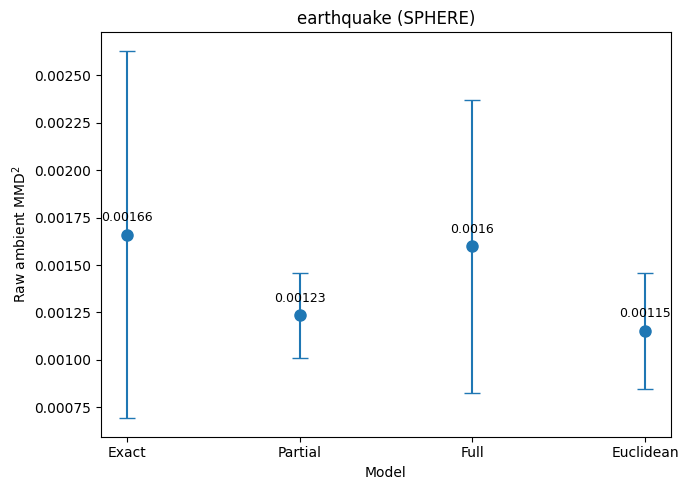

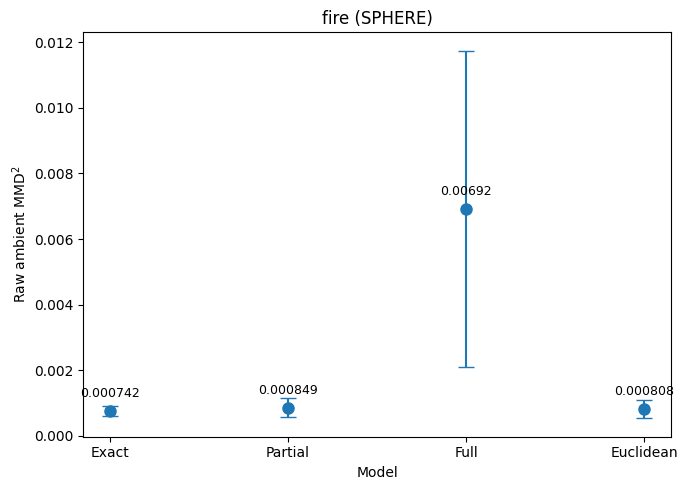

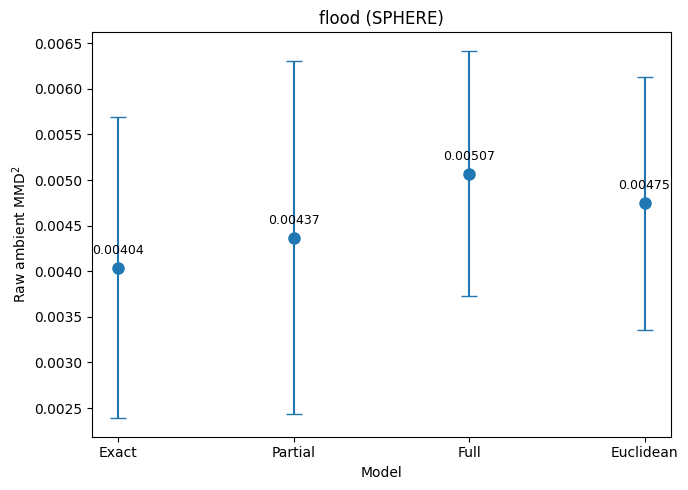

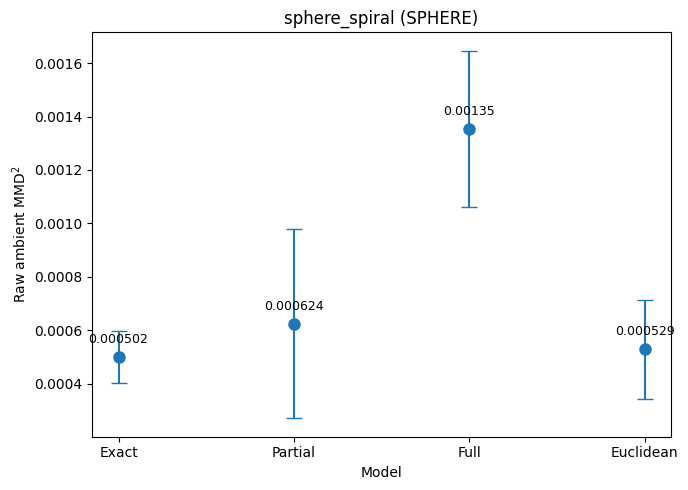

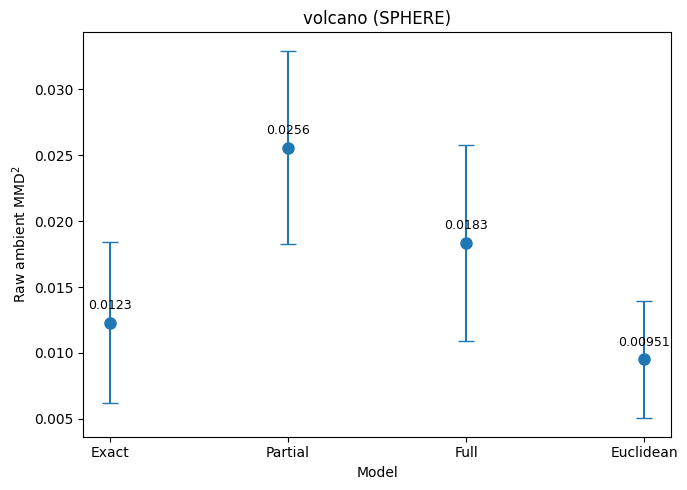

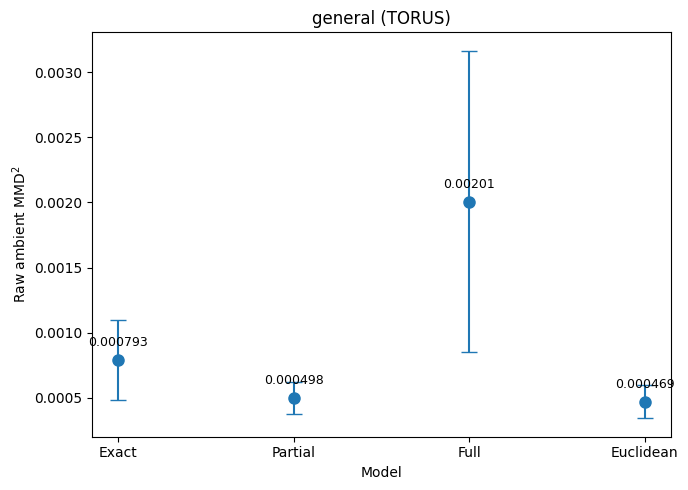

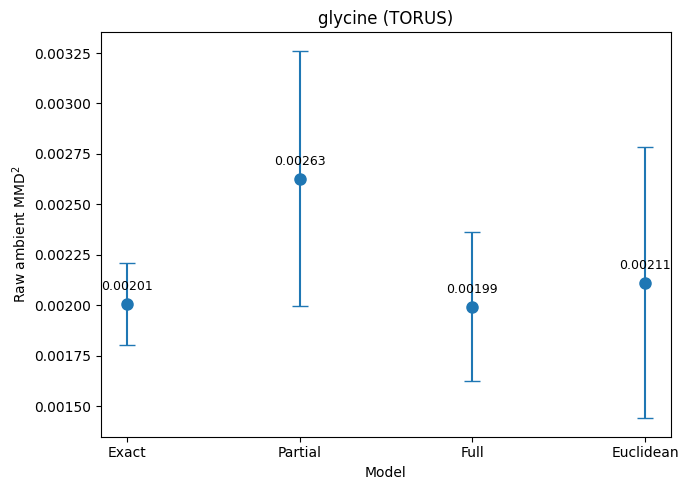

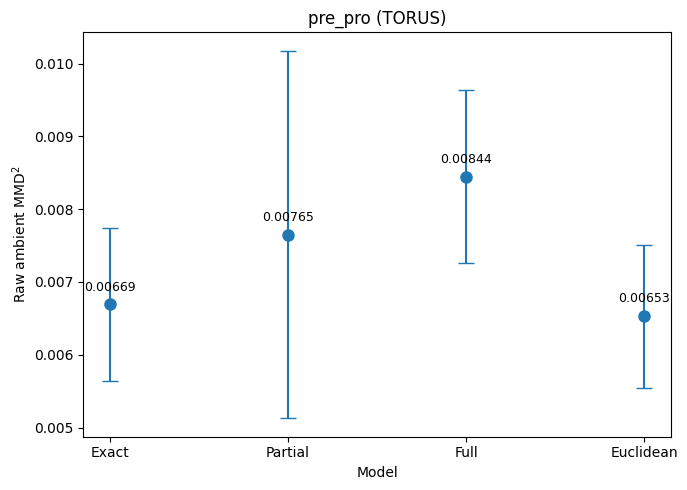

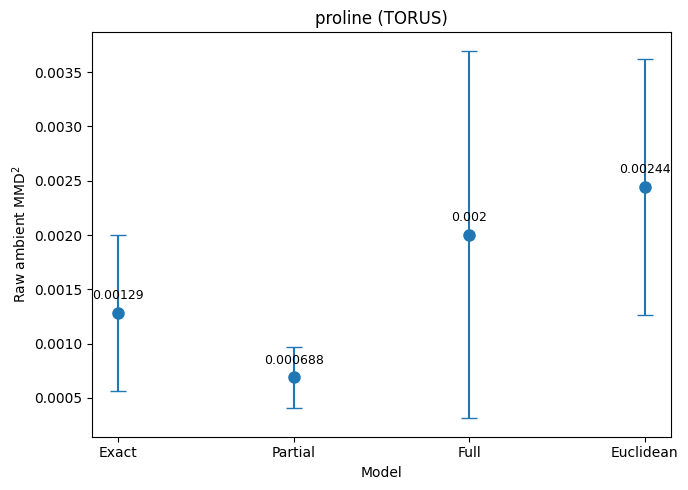

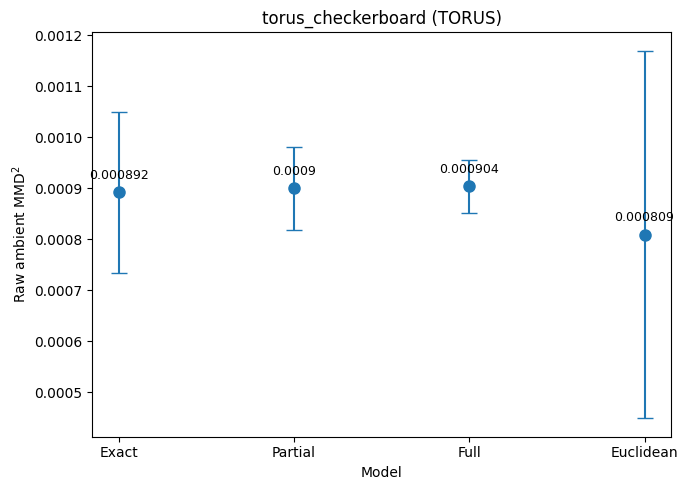

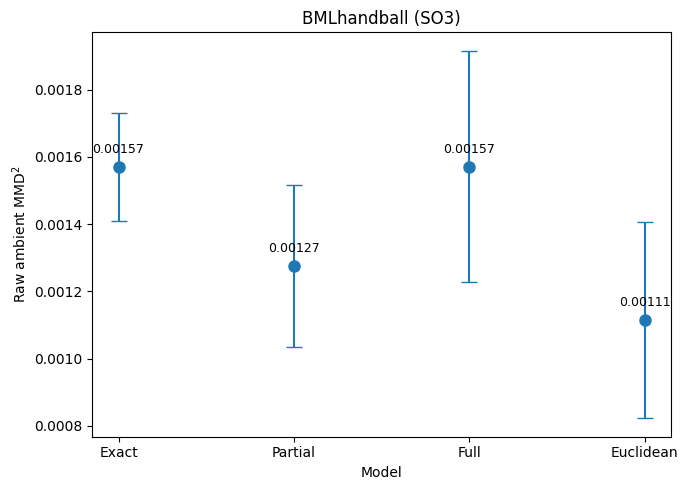

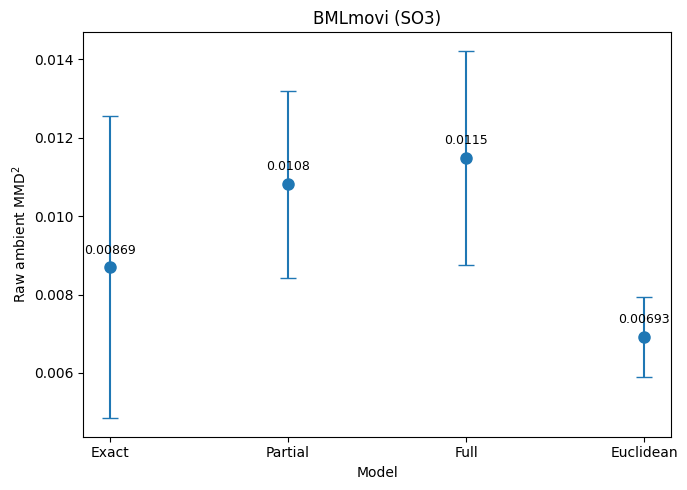

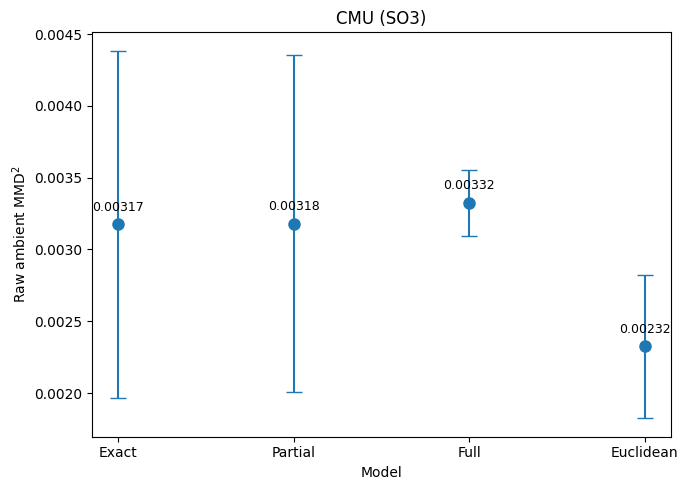

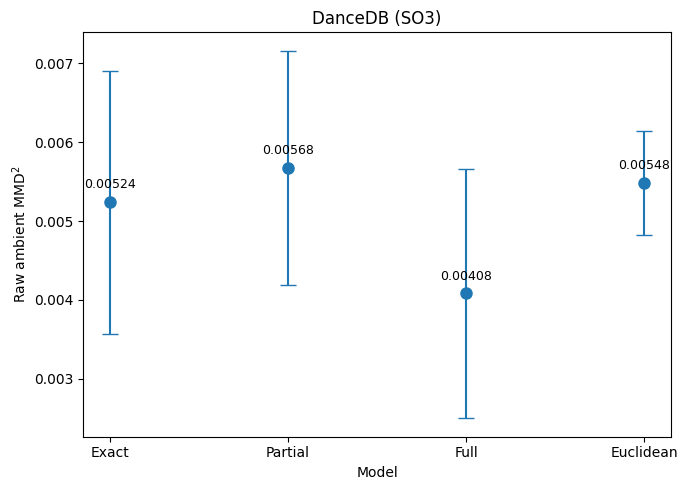

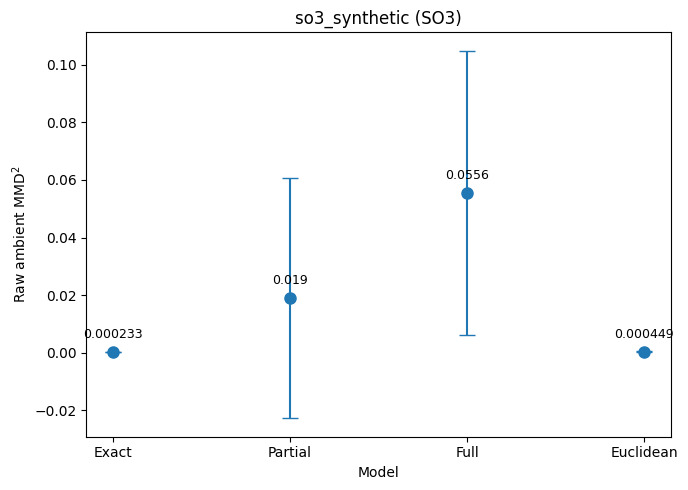

In [6]:
# ============================================================
# Raw ambient MMD²: one plot per dataset
# Mean ± 1 SD across the five final training seeds
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

RAW_MMD_METRIC = "ambient_mmd_sq_raw"

METHOD_ORDER = ["exact", "partial", "full", "euclidean"]

METHOD_LABELS = {
    "exact": "Exact",
    "partial": "Partial",
    "full": "Full",
    "euclidean": "Euclidean",
}

# Get only raw ambient MMD²
raw_mmd = COMBINED_TEST_LONG[
    COMBINED_TEST_LONG["metric"] == RAW_MMD_METRIC
].copy()

# Stable ordering of datasets
manifold_order = {"sphere": 0, "torus": 1, "so3": 2}

dataset_keys = (
    raw_mmd[["manifold", "dataset"]]
    .drop_duplicates()
    .copy()
)

dataset_keys["_manifold_order"] = (
    dataset_keys["manifold"]
    .map(manifold_order)
    .fillna(len(manifold_order))
)

dataset_keys = (
    dataset_keys
    .sort_values(["_manifold_order", "dataset"])
    .drop(columns="_manifold_order")
)


for row in dataset_keys.itertuples(index=False):

    manifold = row.manifold
    dataset = row.dataset

    sub = raw_mmd[
        (raw_mmd["manifold"] == manifold)
        & (raw_mmd["dataset"] == dataset)
    ].copy()

    # Reindex so models always appear in the same order
    sub = (
        sub
        .set_index("method")
        .reindex(METHOD_ORDER)
        .reset_index()
    )

    x = np.arange(len(METHOD_ORDER))

    means = sub["mean_over_training_seeds"].to_numpy(dtype=float)
    sds = sub["sd_over_training_seeds"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.errorbar(
        x,
        means,
        yerr=sds,
        fmt="o",
        markersize=8,
        capsize=6,
        elinewidth=1.5,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [METHOD_LABELS[m] for m in METHOD_ORDER]
    )

    ax.set_xlabel("Model")
    ax.set_ylabel(r"Raw ambient MMD$^2$")
    ax.set_title(
        f"{dataset} ({manifold.upper()})"
    )

    # Add mean value above each point
    for xi, mean, sd in zip(x, means, sds):
        if np.isfinite(mean):
            ax.annotate(
                f"{mean:.3g}",
                (xi, mean),
                xytext=(0, 10),
                textcoords="offset points",
                ha="center",
                fontsize=9,
            )

    fig.tight_layout()

    # Save dissertation-quality versions
    filename = f"raw_mmd_{manifold}_{dataset}"

    fig.savefig(
        FIGURE_DIR / f"{filename}.pdf",
        bbox_inches="tight",
    )

    fig.savefig(
        FIGURE_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


## 6. Best-checkpoint summary

All four final procedures used validation to select the checkpoint whose test result is reported. This table/plot is useful for checking whether the 50,000-step horizon was actually being used, or whether the best validation checkpoints systematically occurred much earlier.


In [9]:

# ============================================================
# 6. Best validation checkpoint locations
# ============================================================

BEST_STEP_BY_SEED = (
    COMBINED_RUNS[
        [
            "manifold",
            "dataset",
            "method",
            "method_label",
            "seed",
            "best_step",
            "best_validation_score",
            "source_run_dir",
        ]
    ]
    .copy()
)

BEST_STEP_SUMMARY = (
    BEST_STEP_BY_SEED
    .groupby(
        ["manifold", "dataset", "method", "method_label"],
        as_index=False,
    )
    .agg(
        mean_best_step=("best_step", "mean"),
        sd_best_step=("best_step", "std"),
        median_best_step=("best_step", "median"),
        min_best_step=("best_step", "min"),
        max_best_step=("best_step", "max"),
        fraction_best_at_50000=(
            "best_step",
            lambda x: float(
                np.mean(np.asarray(x, dtype=float) == 50_000)
            ),
        ),
    )
)

BEST_STEP_SUMMARY["_manifold_order"] = (
    BEST_STEP_SUMMARY["manifold"]
    .map({m: i for i, m in enumerate(MANIFOLD_ORDER)})
    .fillna(len(MANIFOLD_ORDER))
)
BEST_STEP_SUMMARY["_method_order"] = (
    BEST_STEP_SUMMARY["method"]
    .map({m: i for i, m in enumerate(METHOD_ORDER)})
)

BEST_STEP_SUMMARY = (
    BEST_STEP_SUMMARY
    .sort_values(
        ["_manifold_order", "dataset", "_method_order"]
    )
    .drop(columns=["_manifold_order", "_method_order"])
    .reset_index(drop=True)
)

display(BEST_STEP_SUMMARY)

BEST_STEP_BY_SEED.to_csv(
    COMBINED_DIR / "best_step_by_seed.csv",
    index=False,
)
BEST_STEP_SUMMARY.to_csv(
    COMBINED_DIR / "best_step_summary.csv",
    index=False,
)


,manifold,dataset,method,method_label,mean_best_step,sd_best_step,median_best_step,min_best_step,max_best_step,fraction_best_at_50000
0,sphere,earthquake,exact,Exact (geodesic loss),24800.0,10633.672931,22000.0,11000,39500,0.0
1,sphere,earthquake,partial,Partial (graph),15400.0,7797.435476,13500.0,5500,24500,0.0
2,sphere,earthquake,full,Full (graph),15300.0,13108.203538,14500.0,2500,32500,0.0
3,sphere,earthquake,euclidean,Euclidean,10200.0,7604.275113,5000.0,4500,21000,0.0
4,sphere,fire,exact,Exact (geodesic loss),26800.0,17177.747233,24500.0,3000,50000,0.2
5,sphere,fire,partial,Partial (graph),18500.0,5590.169944,17000.0,14000,28000,0.0
6,sphere,fire,full,Full (graph),27800.0,19835.574103,33500.0,500,47500,0.0
7,sphere,fire,euclidean,Euclidean,16000.0,10671.222985,19500.0,4000,29000,0.0
8,sphere,flood,exact,Exact (geodesic loss),17100.0,14104.077425,19000.0,500,38000,0.0
9,sphere,flood,partial,Partial (graph),17000.0,9956.153876,13500.0,9000,32500,0.0


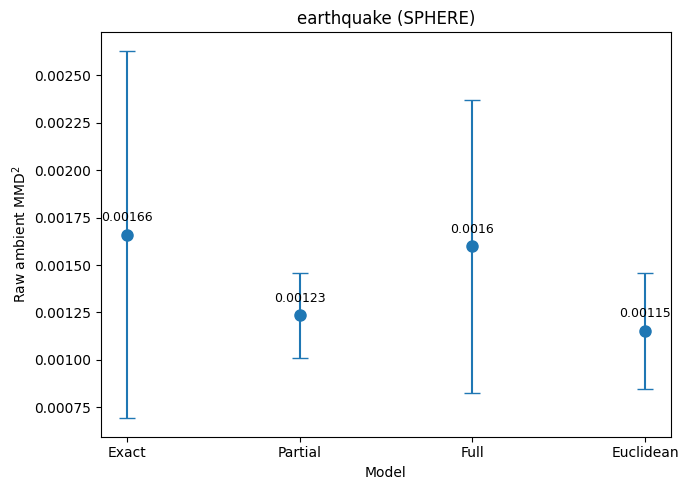

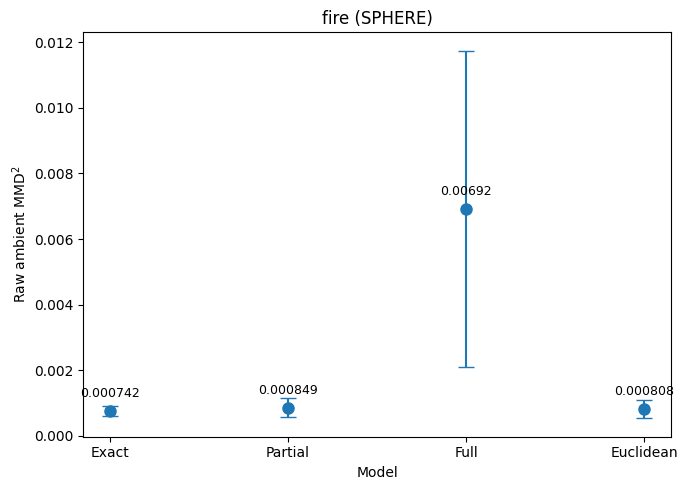

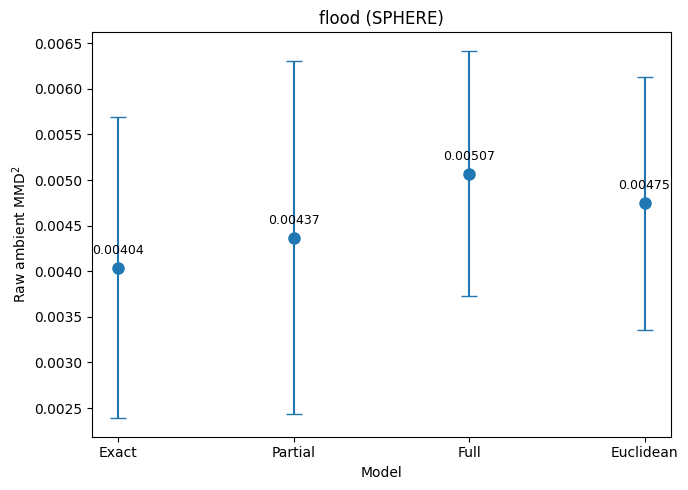

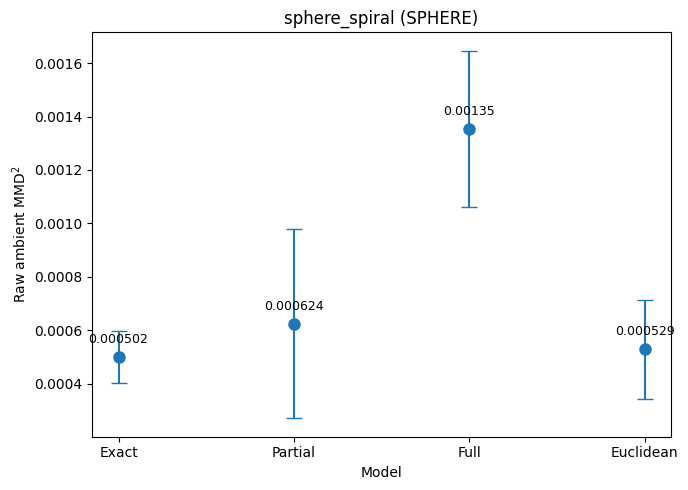

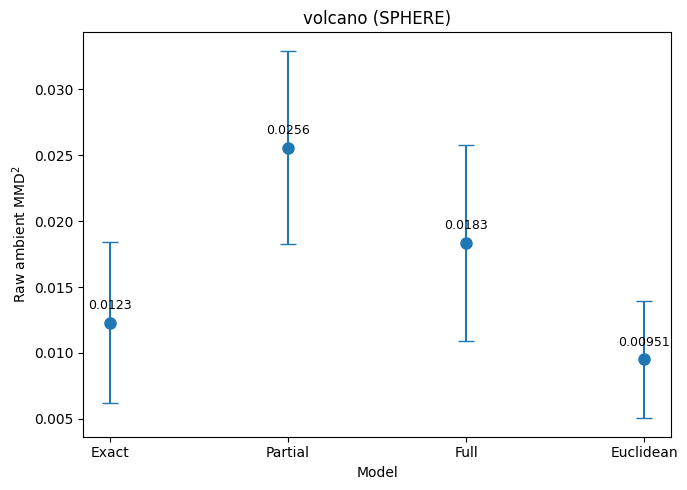

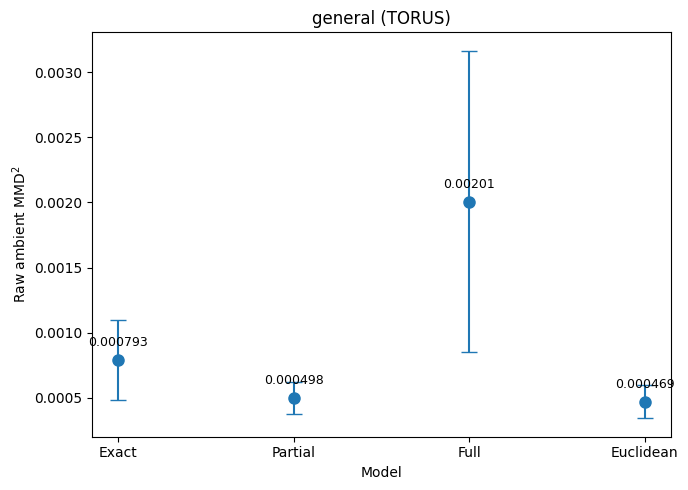

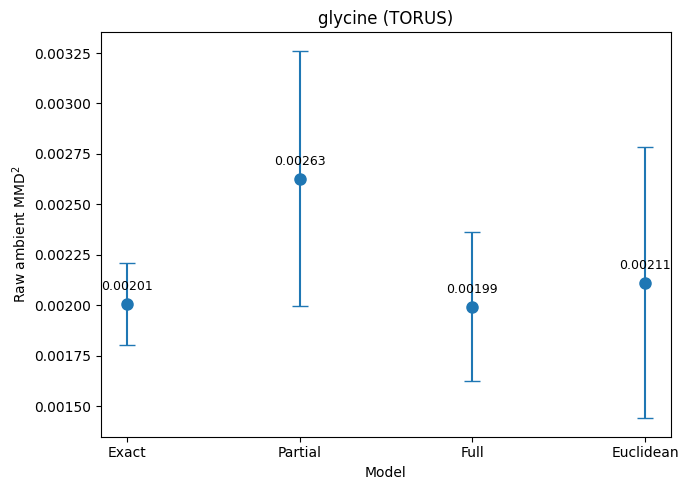

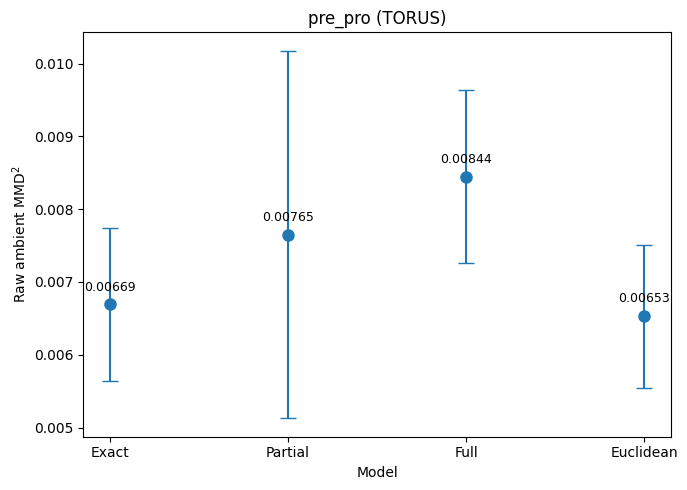

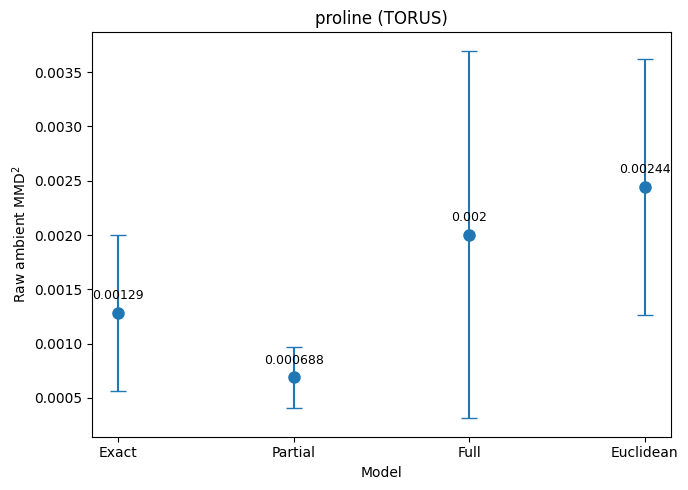

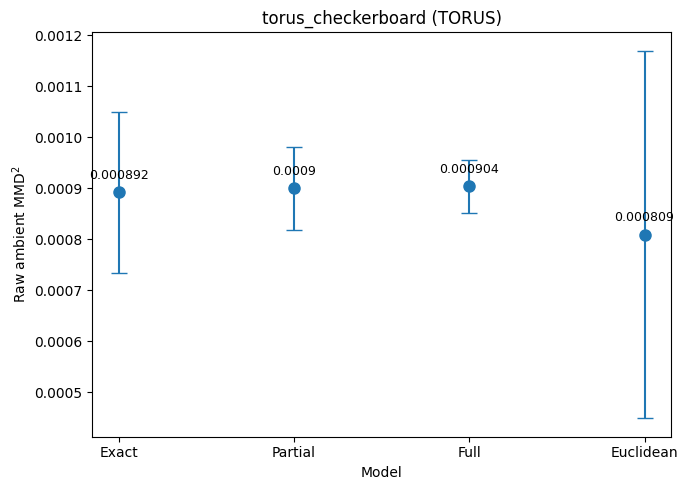

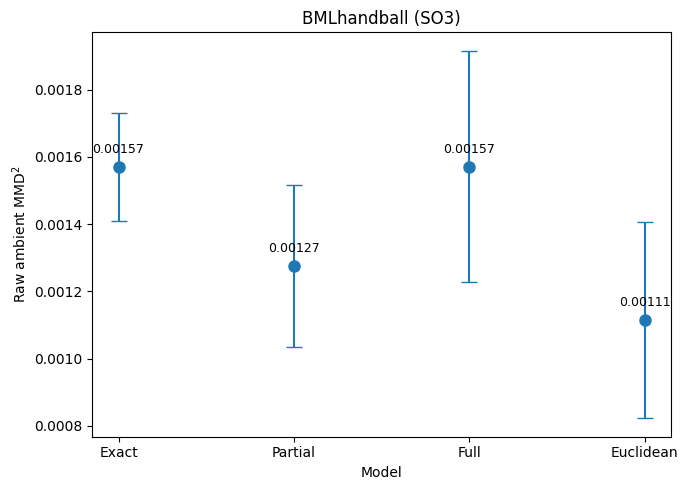

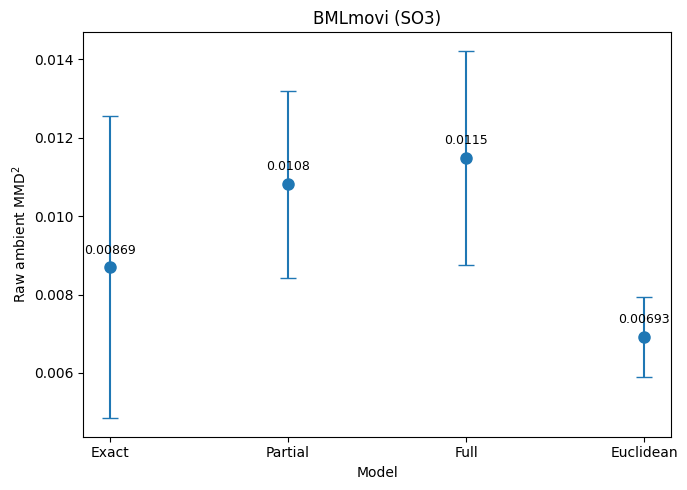

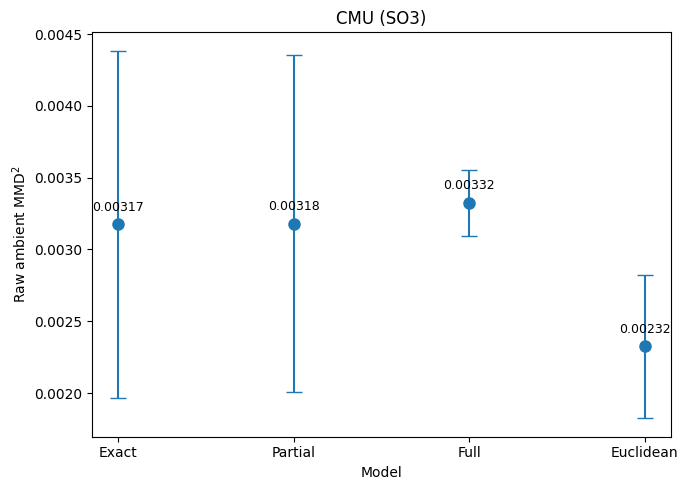

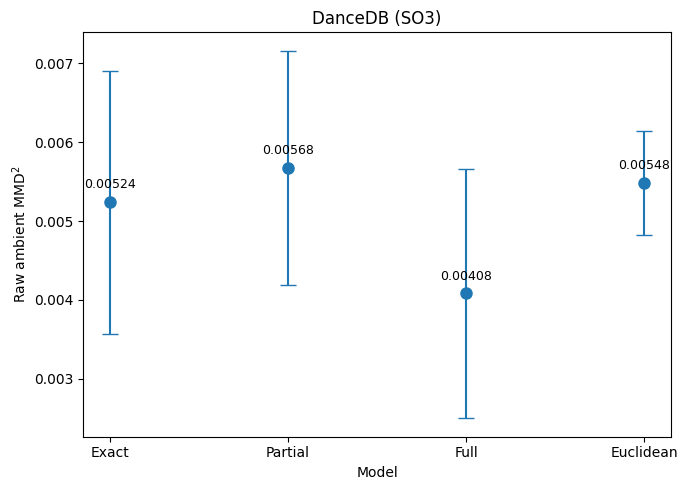

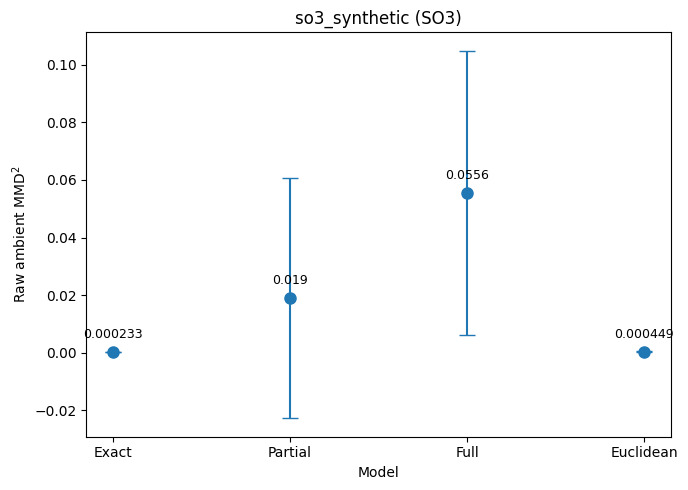

In [10]:
# ============================================================
# Raw ambient MMD²: one plot per dataset
# Mean ± 1 SD across the five final training seeds
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

RAW_MMD_METRIC = "ambient_mmd_sq_raw"

METHOD_ORDER = ["exact", "partial", "full", "euclidean"]

METHOD_LABELS = {
    "exact": "Exact",
    "partial": "Partial",
    "full": "Full",
    "euclidean": "Euclidean",
}

# Get only raw ambient MMD²
raw_mmd = COMBINED_TEST_LONG[
    COMBINED_TEST_LONG["metric"] == RAW_MMD_METRIC
].copy()

# Stable ordering of datasets
manifold_order = {"sphere": 0, "torus": 1, "so3": 2}

dataset_keys = (
    raw_mmd[["manifold", "dataset"]]
    .drop_duplicates()
    .copy()
)

dataset_keys["_manifold_order"] = (
    dataset_keys["manifold"]
    .map(manifold_order)
    .fillna(len(manifold_order))
)

dataset_keys = (
    dataset_keys
    .sort_values(["_manifold_order", "dataset"])
    .drop(columns="_manifold_order")
)


for row in dataset_keys.itertuples(index=False):

    manifold = row.manifold
    dataset = row.dataset

    sub = raw_mmd[
        (raw_mmd["manifold"] == manifold)
        & (raw_mmd["dataset"] == dataset)
    ].copy()

    # Reindex so models always appear in the same order
    sub = (
        sub
        .set_index("method")
        .reindex(METHOD_ORDER)
        .reset_index()
    )

    x = np.arange(len(METHOD_ORDER))

    means = sub["mean_over_training_seeds"].to_numpy(dtype=float)
    sds = sub["sd_over_training_seeds"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.errorbar(
        x,
        means,
        yerr=sds,
        fmt="o",
        markersize=8,
        capsize=6,
        elinewidth=1.5,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [METHOD_LABELS[m] for m in METHOD_ORDER]
    )

    ax.set_xlabel("Model")
    ax.set_ylabel(r"Raw ambient MMD$^2$")
    ax.set_title(
        f"{dataset} ({manifold.upper()})"
    )

    # Add mean value above each point
    for xi, mean, sd in zip(x, means, sds):
        if np.isfinite(mean):
            ax.annotate(
                f"{mean:.3g}",
                (xi, mean),
                xytext=(0, 10),
                textcoords="offset points",
                ha="center",
                fontsize=9,
            )

    fig.tight_layout()

    # Save dissertation-quality versions
    filename = f"raw_mmd_{manifold}_{dataset}"

    fig.savefig(
        FIGURE_DIR / f"{filename}.pdf",
        bbox_inches="tight",
    )

    fig.savefig(
        FIGURE_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [11]:
# ============================================================
# REAL-vs-REAL finite-sample reference for every dataset
# ============================================================
#
# The original experiment pipeline already computed this using:
#   * the fixed TEST pool for each target,
#   * the same sample size as model-vs-test evaluation,
#   * the frozen ambient Gaussian-MMD bandwidth,
#   * repeated independent resampling with seed 2026.
#
# Since this reference depends only on the dataset/evaluation
# protocol, not on the trained model, we recover the canonical
# saved calculation rather than recomputing it differently.
# ============================================================

import json
import numpy as np
import pandas as pd

real_vs_real_rows = []

summary_paths = sorted(
    RESULTS_ROOT.glob("*/*/experiment_summary.json")
)

for path in summary_paths:

    rel = path.relative_to(RESULTS_ROOT)

    if len(rel.parts) < 3:
        continue

    manifold = rel.parts[0]
    dataset = rel.parts[1]

    with open(path, "r") as f:
        obj = json.load(f)

    floor = obj.get("real_vs_real_floor", {})

    ambient = floor.get("ambient_mmd_sq", {})
    intrinsic = floor.get("intrinsic_discrepancy_sq", {})

    if not ambient:
        continue

    real_vs_real_rows.append({
        "manifold": manifold,
        "dataset": dataset,

        "ambient_mmd_sq_mean":
            float(ambient.get("mean", np.nan)),

        "ambient_mmd_sq_std":
            float(ambient.get("std", np.nan)),

        "intrinsic_discrepancy_sq_mean":
            float(intrinsic.get("mean", np.nan))
            if intrinsic else np.nan,

        "intrinsic_discrepancy_sq_std":
            float(intrinsic.get("std", np.nan))
            if intrinsic else np.nan,

        "source_file": str(path),
    })


REAL_VS_REAL = pd.DataFrame(real_vs_real_rows)

if REAL_VS_REAL.empty:
    raise RuntimeError(
        "No saved real-vs-real references were found under "
        f"{RESULTS_ROOT}"
    )

# Make sure there is only one canonical row per target.
duplicate = (
    REAL_VS_REAL
    .groupby(["manifold", "dataset"])
    .size()
    .reset_index(name="n")
)

duplicate = duplicate[duplicate["n"] != 1]

if not duplicate.empty:
    display(duplicate)
    raise RuntimeError(
        "Multiple real-vs-real references were found for at least "
        "one dataset. Inspect before proceeding."
    )


# ------------------------------------------------------------
# Audit against the datasets appearing in the FINAL comparison
# ------------------------------------------------------------

expected_datasets = (
    COMBINED_RUNS[
        ["manifold", "dataset"]
    ]
    .drop_duplicates()
)

floor_audit = expected_datasets.merge(
    REAL_VS_REAL[
        [
            "manifold",
            "dataset",
            "ambient_mmd_sq_mean",
            "ambient_mmd_sq_std",
        ]
    ],
    on=["manifold", "dataset"],
    how="left",
)

missing = floor_audit[
    floor_audit["ambient_mmd_sq_mean"].isna()
]

if not missing.empty:
    print("Missing real-vs-real references:")
    display(missing)
    raise RuntimeError(
        "At least one final dataset has no canonical real-vs-real "
        "ambient MMD reference."
    )


# ------------------------------------------------------------
# Order for display
# ------------------------------------------------------------

_manifold_order = {
    "sphere": 0,
    "torus": 1,
    "so3": 2,
}

REAL_VS_REAL["_order"] = (
    REAL_VS_REAL["manifold"]
    .map(_manifold_order)
    .fillna(99)
)

REAL_VS_REAL = (
    REAL_VS_REAL
    .sort_values(
        ["_order", "dataset"]
    )
    .drop(columns="_order")
    .reset_index(drop=True)
)


print("REAL-vs-REAL FINITE-SAMPLE REFERENCES")
print("=" * 80)

display(
    REAL_VS_REAL[
        [
            "manifold",
            "dataset",
            "ambient_mmd_sq_mean",
            "ambient_mmd_sq_std",
            "intrinsic_discrepancy_sq_mean",
            "intrinsic_discrepancy_sq_std",
        ]
    ]
)

REAL_VS_REAL.to_csv(
    COMBINED_DIR / "real_vs_real_references.csv",
    index=False,
)

print(
    "\nSaved:",
    COMBINED_DIR / "real_vs_real_references.csv",
)

REAL-vs-REAL FINITE-SAMPLE REFERENCES


,manifold,dataset,ambient_mmd_sq_mean,ambient_mmd_sq_std,intrinsic_discrepancy_sq_mean,intrinsic_discrepancy_sq_std
0,sphere,earthquake,0.001908,0.001426,0.002398,0.001677
1,sphere,fire,0.000915,0.000801,0.001087,0.000909
2,sphere,flood,0.001793,0.001161,0.002178,0.001270
3,sphere,sphere_spiral,0.000524,0.000320,0.000744,0.000387
4,sphere,volcano,0.013543,0.007813,0.016852,0.009135
5,torus,general,0.000605,0.000500,0.000798,0.000545
6,torus,glycine,0.000825,0.000550,0.001375,0.000661
7,torus,pre_pro,0.001791,0.000904,0.001899,0.000957
8,torus,proline,0.000923,0.000705,0.001151,0.000797
9,torus,torus_checkerboard,0.000647,0.000275,0.000993,0.000305



Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/real_vs_real_references.csv


Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__earthquake__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__earthquake__ambient_mmd_sq_raw__seed_scatter.png


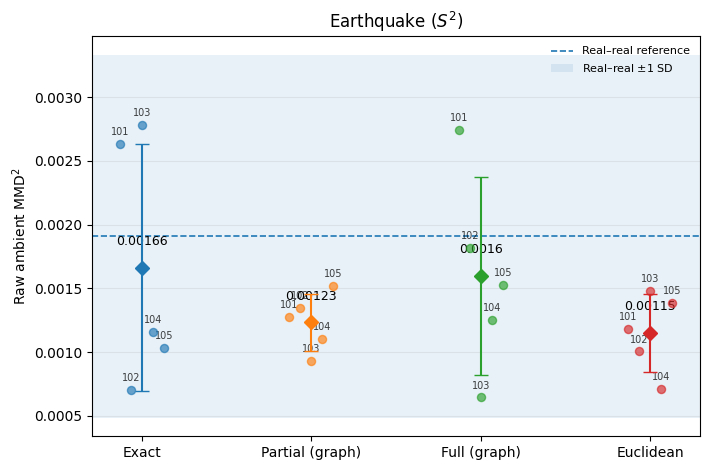

In [12]:
# ============================================================
# FINAL TEST PLOTS:
# mean ± SD + individual training seeds + real-vs-real reference
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

METHOD_LABELS_FINAL = {
    "exact": "Exact",
    "partial": "Partial (graph)",
    "full": "Full (graph)",
    "euclidean": "Euclidean",
}

METHOD_ORDER_FINAL = [
    "exact",
    "partial",
    "full",
    "euclidean",
]


def plot_final_seed_distribution(
    dataset,
    manifold=None,
    metric="ambient_mmd_sq_raw",
    label_seeds=True,
    show_real_reference=True,
    save=True,
):

    # --------------------------------------------------------
    # Locate target
    # --------------------------------------------------------

    df = COMBINED_TEST_BY_SEED[
        (COMBINED_TEST_BY_SEED["dataset"] == dataset)
        & (COMBINED_TEST_BY_SEED["metric"] == metric)
    ].copy()

    if manifold is not None:
        df = df[
            df["manifold"] == manifold
        ].copy()

    if df.empty:
        raise ValueError(
            f"No rows found for dataset={dataset!r}, metric={metric!r}"
        )

    manifolds = df["manifold"].unique()

    if len(manifolds) != 1:
        raise ValueError(
            f"Dataset name {dataset!r} occurs under multiple manifolds: "
            f"{manifolds}. Supply manifold= explicitly."
        )

    manifold = manifolds[0]

    methods = [
        m for m in METHOD_ORDER_FINAL
        if m in set(df["method"])
    ]

    # --------------------------------------------------------
    # Mean and sample SD across independent training seeds
    # --------------------------------------------------------

    summary = (
        df
        .groupby(
            ["method"],
            as_index=False,
        )
        .agg(
            mean=("value", "mean"),
            sd=(
                "value",
                lambda x:
                    float(x.std(ddof=1))
                    if len(x) > 1
                    else np.nan,
            ),
            n=("seed", "nunique"),
        )
    )

    summary["_order"] = (
        summary["method"]
        .map({
            m: i
            for i, m in enumerate(
                METHOD_ORDER_FINAL
            )
        })
    )

    summary = (
        summary
        .sort_values("_order")
        .drop(columns="_order")
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7.2, 4.8)
    )

    x_positions = {
        method: i
        for i, method in enumerate(methods)
    }

    # Fixed deterministic horizontal offsets for seeds 101,...,105.
    # Same seed gets the same horizontal position for every model.
    sorted_all_seeds = sorted(
        set(df["seed"].astype(int))
    )

    if len(sorted_all_seeds) == 1:
        seed_offsets = {
            sorted_all_seeds[0]: 0.0
        }
    else:
        offsets = np.linspace(
            -0.13,
            0.13,
            len(sorted_all_seeds),
        )
        seed_offsets = dict(
            zip(
                sorted_all_seeds,
                offsets,
            )
        )


    # --------------------------------------------------------
    # One method at a time
    # --------------------------------------------------------

    for method in methods:

        method_df = (
            df[
                df["method"] == method
            ]
            .sort_values("seed")
        )

        x0 = x_positions[method]

        row = summary[
            summary["method"] == method
        ].iloc[0]

        mean_value = float(row["mean"])
        sd_value = float(row["sd"])

        # Mean ± SD.
        mean_artist = ax.errorbar(
            x0,
            mean_value,
            yerr=sd_value,
            fmt="D",
            markersize=7,
            capsize=5,
            elinewidth=1.5,
            linewidth=1.5,
            zorder=4,
        )

        # Use the same automatically chosen colour for seed dots.
        colour = mean_artist[0].get_color()

        # Individual independently trained seeds.
        for _, r in method_df.iterrows():

            seed = int(r["seed"])
            value = float(r["value"])

            xpos = (
                x0
                + seed_offsets[seed]
            )

            ax.scatter(
                xpos,
                value,
                s=34,
                color=colour,
                alpha=0.65,
                zorder=5,
            )

            if label_seeds:
                ax.annotate(
                    str(seed),
                    (xpos, value),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    alpha=0.75,
                )


        # Mean numerical annotation
        ax.annotate(
            f"{mean_value:.3g}",
            (x0, mean_value),
            xytext=(0, 14),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )


    # --------------------------------------------------------
    # Real-vs-real reference
    # --------------------------------------------------------

    if show_real_reference:

        floor = REAL_VS_REAL[
            (REAL_VS_REAL["manifold"] == manifold)
            & (REAL_VS_REAL["dataset"] == dataset)
        ]

        if len(floor) == 1:

            floor_mean = float(
                floor.iloc[0][
                    "ambient_mmd_sq_mean"
                ]
            )

            floor_sd = float(
                floor.iloc[0][
                    "ambient_mmd_sq_std"
                ]
            )

            ax.axhline(
                floor_mean,
                linestyle="--",
                linewidth=1.2,
                label="Real–real reference",
            )

            if (
                np.isfinite(floor_sd)
                and floor_sd > 0
            ):
                ax.axhspan(
                    max(0.0, floor_mean - floor_sd),
                    floor_mean + floor_sd,
                    alpha=0.10,
                    label=r"Real–real $\pm 1$ SD",
                )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(len(methods))
    )

    ax.set_xticklabels([
        METHOD_LABELS_FINAL[m]
        for m in methods
    ])

    if metric == "ambient_mmd_sq_raw":
        ylabel = r"Raw ambient MMD$^2$"
    else:
        ylabel = metric

    ax.set_ylabel(ylabel)

    pretty_dataset = (
        dataset
        .replace("_", " ")
        .title()
    )

    manifold_title = {
        "sphere": r"$S^2$",
        "torus": r"$T^2$",
        "so3": r"$SO(3)$",
    }.get(
        manifold,
        manifold,
    )

    ax.set_title(
        f"{pretty_dataset} ({manifold_title})"
    )

    ax.grid(
        axis="y",
        alpha=0.22,
    )

    # MMD² is non-negative.
    current_bottom, current_top = ax.get_ylim()

    if current_bottom < 0:
        ax.set_ylim(
            bottom=0,
            top=current_top,
        )

    if show_real_reference:
        ax.legend(
            frameon=False,
            fontsize=8,
        )

    fig.tight_layout()


    # --------------------------------------------------------
    # Save dissertation-ready files
    # --------------------------------------------------------

    if save:

        stem = (
            f"{manifold}__{dataset}"
            f"__{metric}__seed_scatter"
        )

        pdf_path = (
            FIGURE_DIR
            / f"{stem}.pdf"
        )

        png_path = (
            FIGURE_DIR
            / f"{stem}.png"
        )

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
        )

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", pdf_path)
        print("Saved:", png_path)

    return fig


# ============================================================
# Example: reproduce your Earthquake figure in the new format
# ============================================================

plot_final_seed_distribution(
    dataset="earthquake",
    manifold="sphere",
    metric="ambient_mmd_sq_raw",
    label_seeds=True,
    show_real_reference=True,
    save=True,
)

plt.show()

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/so3__BMLhandball__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/so3__BMLhandball__ambient_mmd_sq_raw__seed_scatter.png


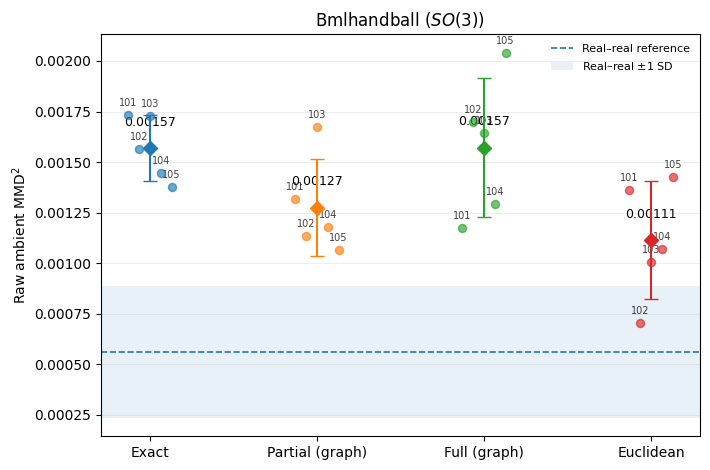

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/so3__BMLmovi__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/so3__BMLmovi__ambient_mmd_sq_raw__seed_scatter.png


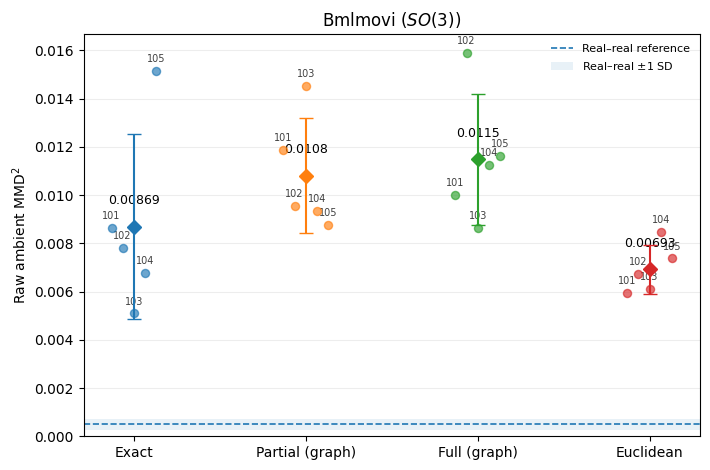

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/so3__CMU__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/so3__CMU__ambient_mmd_sq_raw__seed_scatter.png


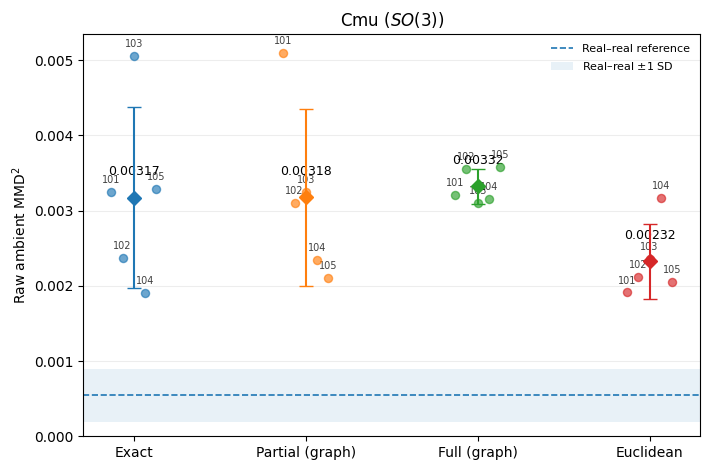

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/so3__DanceDB__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/so3__DanceDB__ambient_mmd_sq_raw__seed_scatter.png


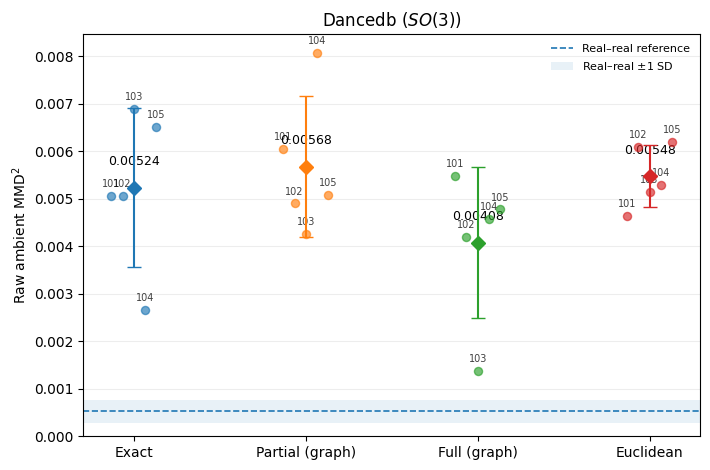

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/so3__so3_synthetic__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/so3__so3_synthetic__ambient_mmd_sq_raw__seed_scatter.png


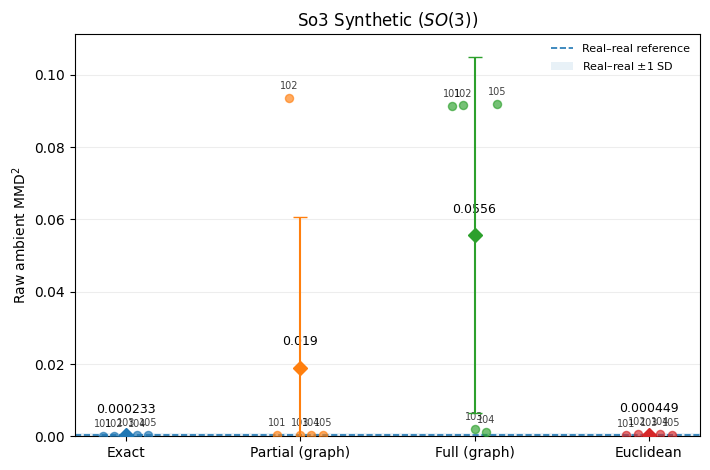

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__earthquake__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__earthquake__ambient_mmd_sq_raw__seed_scatter.png


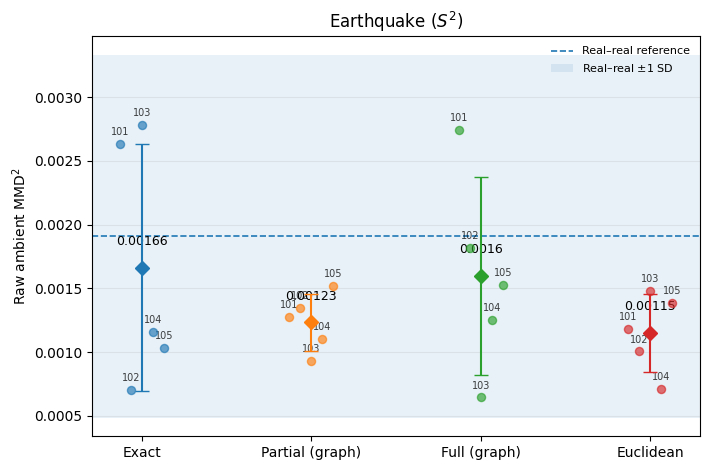

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__fire__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__fire__ambient_mmd_sq_raw__seed_scatter.png


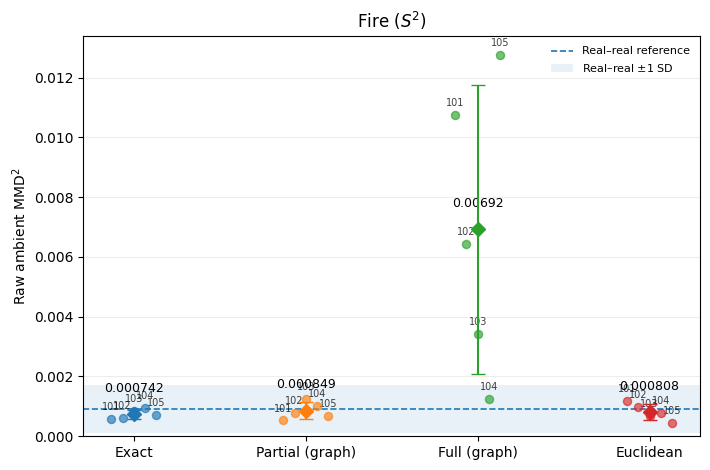

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__flood__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__flood__ambient_mmd_sq_raw__seed_scatter.png


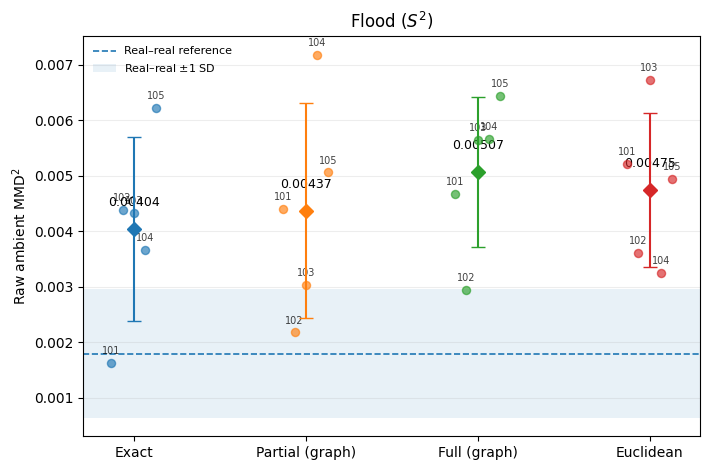

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__sphere_spiral__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__sphere_spiral__ambient_mmd_sq_raw__seed_scatter.png


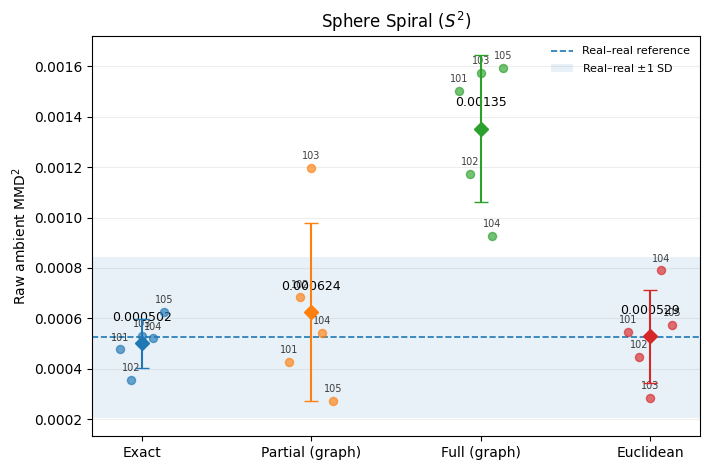

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__volcano__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__volcano__ambient_mmd_sq_raw__seed_scatter.png


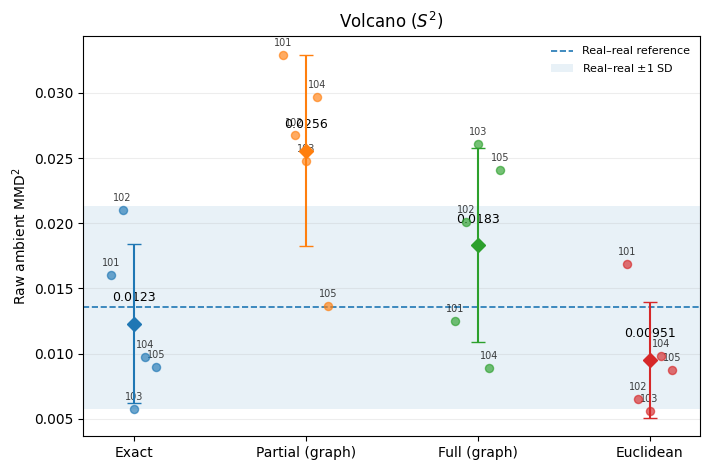

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/torus__general__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/torus__general__ambient_mmd_sq_raw__seed_scatter.png


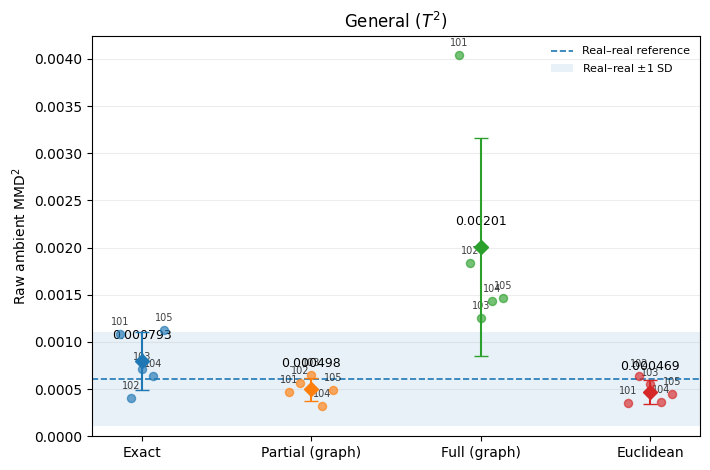

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/torus__glycine__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/torus__glycine__ambient_mmd_sq_raw__seed_scatter.png


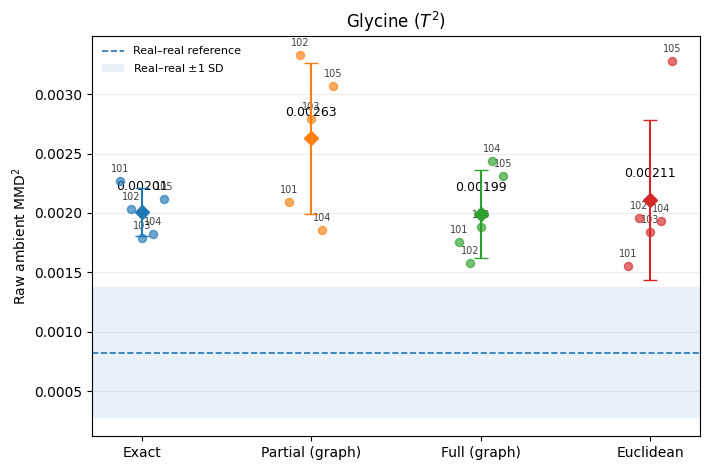

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/torus__pre_pro__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/torus__pre_pro__ambient_mmd_sq_raw__seed_scatter.png


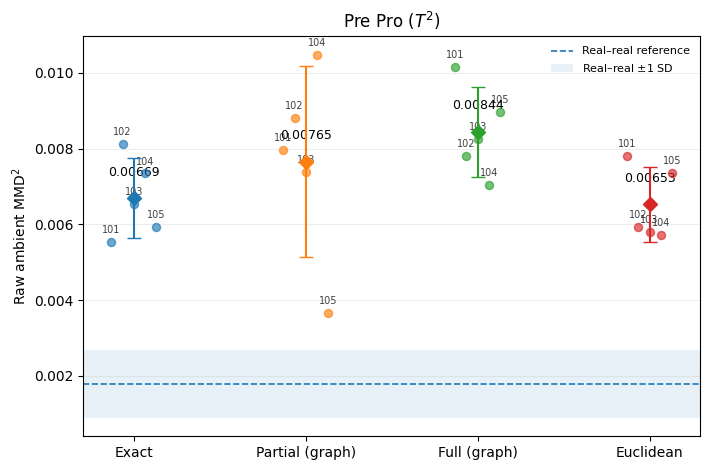

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/torus__proline__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/torus__proline__ambient_mmd_sq_raw__seed_scatter.png


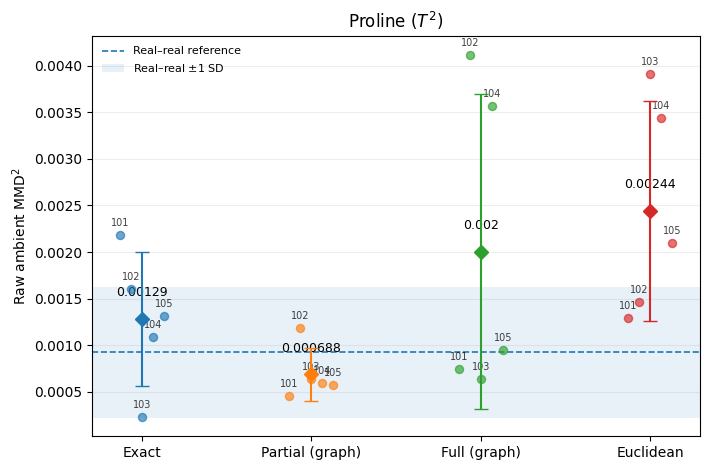

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/torus__torus_checkerboard__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/torus__torus_checkerboard__ambient_mmd_sq_raw__seed_scatter.png


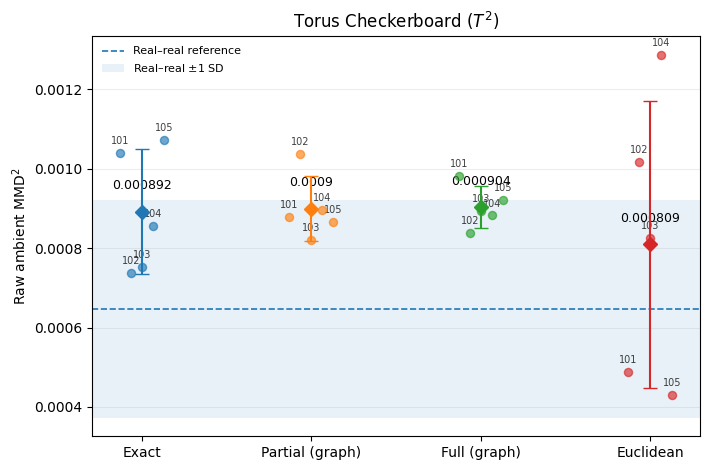

In [13]:
for row in (
    COMBINED_RUNS[
        ["manifold", "dataset"]
    ]
    .drop_duplicates()
    .itertuples(index=False)
):

    plot_final_seed_distribution(
        dataset=row.dataset,
        manifold=row.manifold,
        metric="ambient_mmd_sq_raw",
        label_seeds=True,
        show_real_reference=True,
        save=True,
    )

    plt.show()
    plt.close()

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__earthquake__ambient_mmd_sq_raw__seed_scatter.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/sphere__earthquake__ambient_mmd_sq_raw__seed_scatter.png


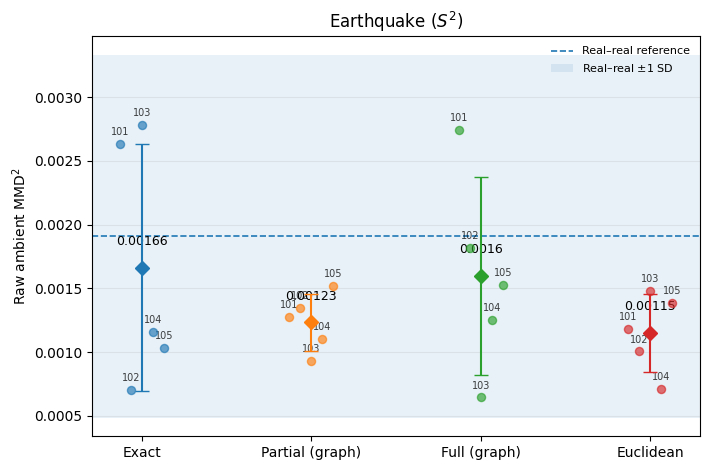

In [14]:
# ============================================================
# FINAL TEST PLOTS:
# mean ± SD + individual training seeds + real-vs-real reference
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

METHOD_LABELS_FINAL = {
    "exact": "Exact",
    "partial": "Partial (graph)",
    "full": "Full (graph)",
    "euclidean": "Euclidean",
}

METHOD_ORDER_FINAL = [
    "exact",
    "partial",
    "full",
    "euclidean",
]


def plot_final_seed_distribution(
    dataset,
    manifold=None,
    metric="ambient_mmd_sq_raw",
    label_seeds=True,
    show_real_reference=True,
    save=True,
):

    # --------------------------------------------------------
    # Locate target
    # --------------------------------------------------------

    df = COMBINED_TEST_BY_SEED[
        (COMBINED_TEST_BY_SEED["dataset"] == dataset)
        & (COMBINED_TEST_BY_SEED["metric"] == metric)
    ].copy()

    if manifold is not None:
        df = df[
            df["manifold"] == manifold
        ].copy()

    if df.empty:
        raise ValueError(
            f"No rows found for dataset={dataset!r}, metric={metric!r}"
        )

    manifolds = df["manifold"].unique()

    if len(manifolds) != 1:
        raise ValueError(
            f"Dataset name {dataset!r} occurs under multiple manifolds: "
            f"{manifolds}. Supply manifold= explicitly."
        )

    manifold = manifolds[0]

    methods = [
        m for m in METHOD_ORDER_FINAL
        if m in set(df["method"])
    ]

    # --------------------------------------------------------
    # Mean and sample SD across independent training seeds
    # --------------------------------------------------------

    summary = (
        df
        .groupby(
            ["method"],
            as_index=False,
        )
        .agg(
            mean=("value", "mean"),
            sd=(
                "value",
                lambda x:
                    float(x.std(ddof=1))
                    if len(x) > 1
                    else np.nan,
            ),
            n=("seed", "nunique"),
        )
    )

    summary["_order"] = (
        summary["method"]
        .map({
            m: i
            for i, m in enumerate(
                METHOD_ORDER_FINAL
            )
        })
    )

    summary = (
        summary
        .sort_values("_order")
        .drop(columns="_order")
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7.2, 4.8)
    )

    x_positions = {
        method: i
        for i, method in enumerate(methods)
    }

    # Fixed deterministic horizontal offsets for seeds 101,...,105.
    # Same seed gets the same horizontal position for every model.
    sorted_all_seeds = sorted(
        set(df["seed"].astype(int))
    )

    if len(sorted_all_seeds) == 1:
        seed_offsets = {
            sorted_all_seeds[0]: 0.0
        }
    else:
        offsets = np.linspace(
            -0.13,
            0.13,
            len(sorted_all_seeds),
        )
        seed_offsets = dict(
            zip(
                sorted_all_seeds,
                offsets,
            )
        )


    # --------------------------------------------------------
    # One method at a time
    # --------------------------------------------------------

    for method in methods:

        method_df = (
            df[
                df["method"] == method
            ]
            .sort_values("seed")
        )

        x0 = x_positions[method]

        row = summary[
            summary["method"] == method
        ].iloc[0]

        mean_value = float(row["mean"])
        sd_value = float(row["sd"])

        # Mean ± SD.
        mean_artist = ax.errorbar(
            x0,
            mean_value,
            yerr=sd_value,
            fmt="D",
            markersize=7,
            capsize=5,
            elinewidth=1.5,
            linewidth=1.5,
            zorder=4,
        )

        # Use the same automatically chosen colour for seed dots.
        colour = mean_artist[0].get_color()

        # Individual independently trained seeds.
        for _, r in method_df.iterrows():

            seed = int(r["seed"])
            value = float(r["value"])

            xpos = (
                x0
                + seed_offsets[seed]
            )

            ax.scatter(
                xpos,
                value,
                s=34,
                color=colour,
                alpha=0.65,
                zorder=5,
            )

            if label_seeds:
                ax.annotate(
                    str(seed),
                    (xpos, value),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    alpha=0.75,
                )


        # Mean numerical annotation
        ax.annotate(
            f"{mean_value:.3g}",
            (x0, mean_value),
            xytext=(0, 14),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )


    # --------------------------------------------------------
    # Real-vs-real reference
    # --------------------------------------------------------

    if show_real_reference:

        floor = REAL_VS_REAL[
            (REAL_VS_REAL["manifold"] == manifold)
            & (REAL_VS_REAL["dataset"] == dataset)
        ]

        if len(floor) == 1:

            floor_mean = float(
                floor.iloc[0][
                    "ambient_mmd_sq_mean"
                ]
            )

            floor_sd = float(
                floor.iloc[0][
                    "ambient_mmd_sq_std"
                ]
            )

            ax.axhline(
                floor_mean,
                linestyle="--",
                linewidth=1.2,
                label="Real–real reference",
            )

            if (
                np.isfinite(floor_sd)
                and floor_sd > 0
            ):
                ax.axhspan(
                    max(0.0, floor_mean - floor_sd),
                    floor_mean + floor_sd,
                    alpha=0.10,
                    label=r"Real–real $\pm 1$ SD",
                )


    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(len(methods))
    )

    ax.set_xticklabels([
        METHOD_LABELS_FINAL[m]
        for m in methods
    ])

    if metric == "ambient_mmd_sq_raw":
        ylabel = r"Raw ambient MMD$^2$"
    else:
        ylabel = metric

    ax.set_ylabel(ylabel)

    pretty_dataset = (
        dataset
        .replace("_", " ")
        .title()
    )

    manifold_title = {
        "sphere": r"$S^2$",
        "torus": r"$T^2$",
        "so3": r"$SO(3)$",
    }.get(
        manifold,
        manifold,
    )

    ax.set_title(
        f"{pretty_dataset} ({manifold_title})"
    )

    ax.grid(
        axis="y",
        alpha=0.22,
    )

    # MMD² is non-negative.
    current_bottom, current_top = ax.get_ylim()

    if current_bottom < 0:
        ax.set_ylim(
            bottom=0,
            top=current_top,
        )

    if show_real_reference:
        ax.legend(
            frameon=False,
            fontsize=8,
        )

    fig.tight_layout()


    # --------------------------------------------------------
    # Save dissertation-ready files
    # --------------------------------------------------------

    if save:

        stem = (
            f"{manifold}__{dataset}"
            f"__{metric}__seed_scatter"
        )

        pdf_path = (
            FIGURE_DIR
            / f"{stem}.pdf"
        )

        png_path = (
            FIGURE_DIR
            / f"{stem}.png"
        )

        fig.savefig(
            pdf_path,
            bbox_inches="tight",
        )

        fig.savefig(
            png_path,
            dpi=300,
            bbox_inches="tight",
        )

        print("Saved:", pdf_path)
        print("Saved:", png_path)

    return fig


# ============================================================
# Example: reproduce your Earthquake figure in the new format
# ============================================================

plot_final_seed_distribution(
    dataset="earthquake",
    manifold="sphere",
    metric="ambient_mmd_sq_raw",
    label_seeds=True,
    show_real_reference=True,
    save=True,
)

plt.show()


## 7. Initial dissertation figures

These are intentionally simple result-comparison figures rather than highly tuned publication figures. Each plot uses the mean across final training seeds with ±1 SD error bars.

The helper is generic, so later you can call it with any metric stored in the final JSON files. Each figure is also saved as both **PDF** and **300-dpi PNG**.


In [15]:

# ============================================================
# 7. Generic grouped result plot
# ============================================================

def plot_final_metric(
    metric,
    ylabel=None,
    title=None,
    filename_stub=None,
    log_y=False,
):
    data = COMBINED_TEST_LONG[
        COMBINED_TEST_LONG["metric"] == metric
    ].copy()

    if data.empty:
        print(f"[skip] metric not available: {metric}")
        return

    # Stable ordering by manifold family, then dataset.
    data["_manifold_order"] = (
        data["manifold"]
        .map({m: i for i, m in enumerate(MANIFOLD_ORDER)})
        .fillna(len(MANIFOLD_ORDER))
    )
    data = data.sort_values(
        ["_manifold_order", "dataset", "method"]
    )

    dataset_keys = (
        data[["manifold", "dataset"]]
        .drop_duplicates()
        .sort_values(
            ["manifold", "dataset"],
            key=lambda s: (
                s.map({m: i for i, m in enumerate(MANIFOLD_ORDER)})
                if s.name == "manifold"
                else s
            ),
        )
    )

    dataset_keys = [
        (r.manifold, r.dataset)
        for r in dataset_keys.itertuples(index=False)
    ]

    x = np.arange(len(dataset_keys), dtype=float)
    n_methods = len(METHOD_ORDER)
    total_width = 0.82
    width = total_width / n_methods

    fig, ax = plt.subplots(
        figsize=(max(12, 1.15 * len(dataset_keys)), 6.2)
    )

    for j, method in enumerate(METHOD_ORDER):
        sub = data[data["method"] == method].copy()
        lookup = {
            (r.manifold, r.dataset):
                (
                    r.mean_over_training_seeds,
                    r.sd_over_training_seeds,
                )
            for r in sub.itertuples(index=False)
        }

        means = []
        sds = []
        for key in dataset_keys:
            mean, sd = lookup.get(key, (np.nan, np.nan))
            means.append(mean)
            sds.append(sd)

        offset = (
            j - (n_methods - 1) / 2
        ) * width

        ax.bar(
            x + offset,
            means,
            width=width,
            yerr=sds,
            capsize=2.5,
            label=SOURCE_RUNS[method]["method_label"],
        )

    labels = [
        f"{manifold}\n{dataset}"
        for manifold, dataset in dataset_keys
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_ylabel(ylabel or metric)
    ax.set_title(title or metric)
    ax.legend()

    if log_y:
        positive = data["mean_over_training_seeds"] > 0
        if positive.all():
            ax.set_yscale("log")
        else:
            print(
                f"[note] {metric}: not using log scale because "
                "at least one aggregated value is non-positive."
            )

    fig.tight_layout()

    if filename_stub is None:
        filename_stub = metric

    pdf_path = FIGURE_DIR / f"{filename_stub}.pdf"
    png_path = FIGURE_DIR / f"{filename_stub}.png"

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


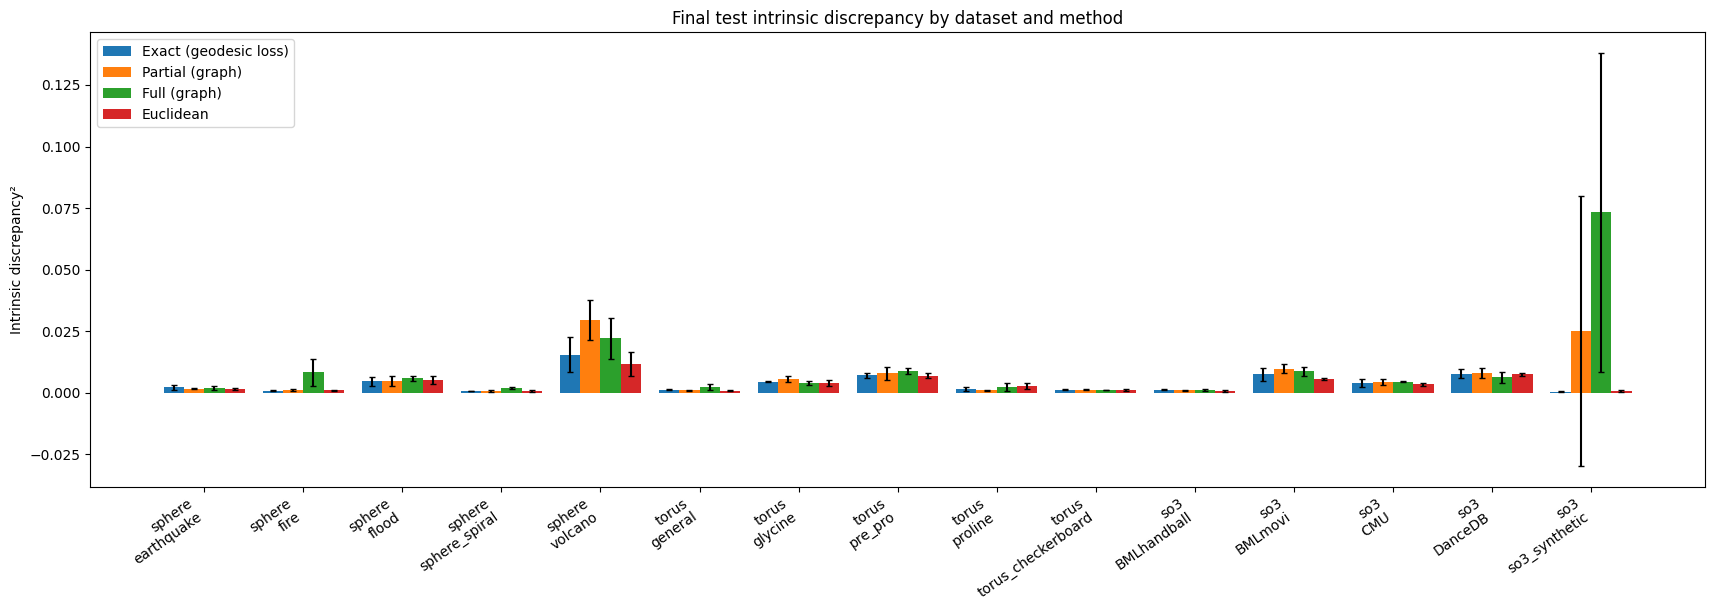

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/final_intrinsic_discrepancy.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/final_intrinsic_discrepancy.png


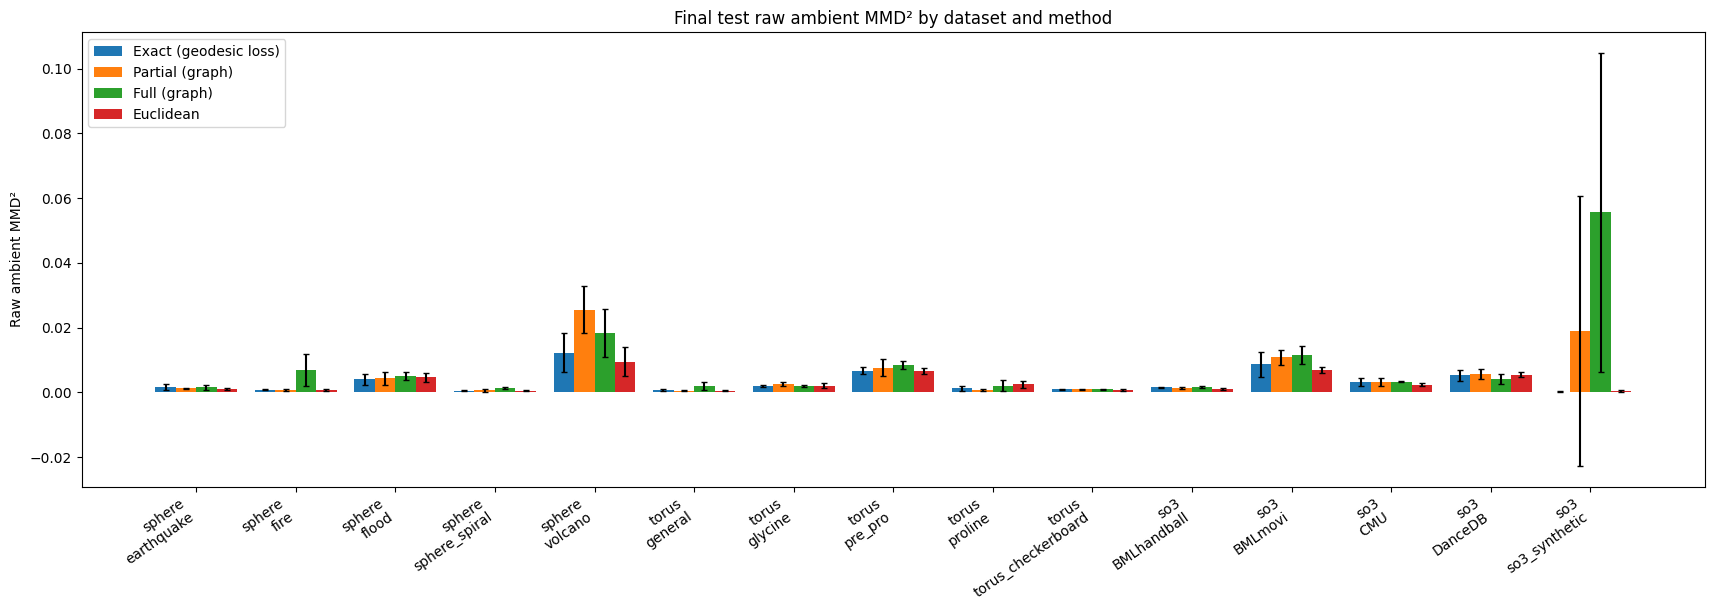

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/final_raw_ambient_mmd.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/final_raw_ambient_mmd.png


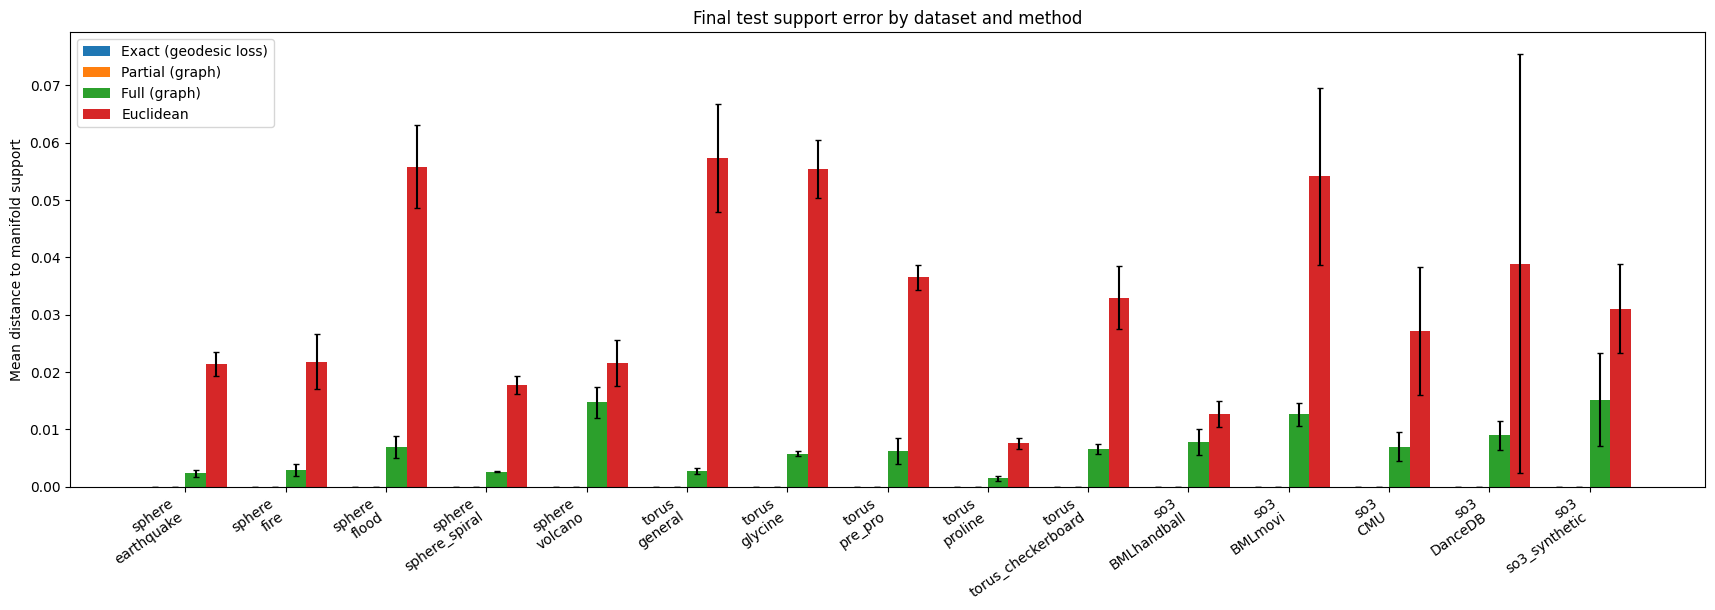

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/final_support_mean.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/final_support_mean.png


In [16]:

# ============================================================
# 8. Three useful first-pass dissertation figures
# ============================================================

plot_final_metric(
    "intrinsic_discrepancy_sq_projected",
    ylabel="Intrinsic discrepancy²",
    title="Final test intrinsic discrepancy by dataset and method",
    filename_stub="final_intrinsic_discrepancy",
    log_y=False,
)

plot_final_metric(
    "ambient_mmd_sq_raw",
    ylabel="Raw ambient MMD²",
    title="Final test raw ambient MMD² by dataset and method",
    filename_stub="final_raw_ambient_mmd",
    log_y=False,
)

plot_final_metric(
    "support_mean",
    ylabel="Mean distance to manifold support",
    title="Final test support error by dataset and method",
    filename_stub="final_support_mean",
    log_y=False,
)


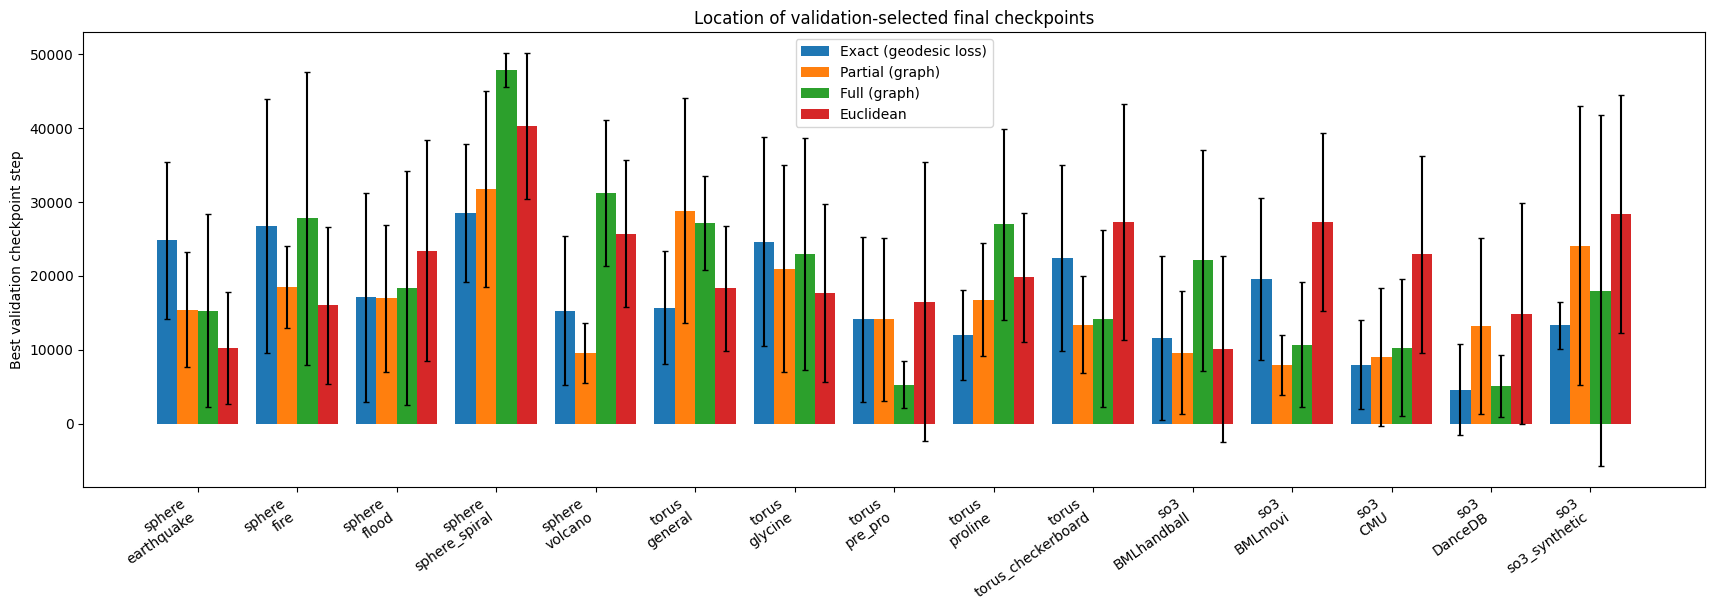

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/best_validation_checkpoint_step.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/figures/best_validation_checkpoint_step.png


In [17]:

# ============================================================
# 9. Best-checkpoint figure
# ============================================================

def plot_best_steps():
    data = BEST_STEP_SUMMARY.copy()

    dataset_keys = (
        data[["manifold", "dataset"]]
        .drop_duplicates()
        .copy()
    )
    dataset_keys["_manifold_order"] = (
        dataset_keys["manifold"]
        .map({m: i for i, m in enumerate(MANIFOLD_ORDER)})
        .fillna(len(MANIFOLD_ORDER))
    )
    dataset_keys = (
        dataset_keys
        .sort_values(["_manifold_order", "dataset"])
        .drop(columns="_manifold_order")
    )
    dataset_keys = [
        (r.manifold, r.dataset)
        for r in dataset_keys.itertuples(index=False)
    ]

    x = np.arange(len(dataset_keys), dtype=float)
    n_methods = len(METHOD_ORDER)
    total_width = 0.82
    width = total_width / n_methods

    fig, ax = plt.subplots(
        figsize=(max(12, 1.15 * len(dataset_keys)), 6.2)
    )

    for j, method in enumerate(METHOD_ORDER):
        sub = data[data["method"] == method]
        lookup = {
            (r.manifold, r.dataset):
                (r.mean_best_step, r.sd_best_step)
            for r in sub.itertuples(index=False)
        }

        means = []
        sds = []
        for key in dataset_keys:
            mean, sd = lookup.get(key, (np.nan, np.nan))
            means.append(mean)
            sds.append(sd)

        offset = (
            j - (n_methods - 1) / 2
        ) * width

        ax.bar(
            x + offset,
            means,
            width=width,
            yerr=sds,
            capsize=2.5,
            label=SOURCE_RUNS[method]["method_label"],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{m}\n{d}" for m, d in dataset_keys],
        rotation=35,
        ha="right",
    )
    ax.set_ylabel("Best validation checkpoint step")
    ax.set_title("Location of validation-selected final checkpoints")
    ax.legend()

    fig.tight_layout()

    pdf_path = FIGURE_DIR / "best_validation_checkpoint_step.pdf"
    png_path = FIGURE_DIR / "best_validation_checkpoint_step.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", pdf_path)
    print("Saved:", png_path)


plot_best_steps()


In [18]:
# ============================================================
# GRADIENT-CLIPPING USAGE AUDIT
#
# Reads existing saved checkpoint histories ONLY.
# No training, no retuning, no test-set changes.
#
# gradient_norm is the PRE-CLIPPING total gradient norm returned
# by torch.nn.utils.clip_grad_norm_().
#
# Therefore:
#     gradient_norm > 1.0  ==> gradient clipping was active
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import torch
from IPython.display import display

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1"
)

GRAD_CLIP_THRESHOLD = 1.0

# Set to None to inspect EVERY saved run with gradient history.
#
# Or, for example:
# PHASE_FILTER = {"final"}
#
# For the old 15k experiment only.
PHASE_FILTER = None


# ------------------------------------------------------------
# Safe checkpoint loader
# ------------------------------------------------------------

def safe_torch_load(path):
    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location="cpu",
        )


# ------------------------------------------------------------
# Scan all checkpoint histories
# ------------------------------------------------------------

run_rows = []
checkpoint_files = sorted(
    RESULTS_ROOT.glob("*/*/*/**/*.pt")
)

print(f"Checkpoint files found: {len(checkpoint_files)}")

for path in checkpoint_files:

    # Expected base structure:
    # RESULTS_ROOT / manifold / dataset / method / ...
    try:
        relative = path.relative_to(RESULTS_ROOT)
    except ValueError:
        continue

    parts = relative.parts

    if len(parts) < 4:
        continue

    manifold = parts[0]
    dataset = parts[1]
    method = parts[2]

    if manifold not in {"sphere", "torus", "so3"}:
        continue

    if method not in {
        "exact",
        "partial",
        "full",
        "euclidean",
    }:
        continue

    try:
        saved = safe_torch_load(path)
    except Exception as e:
        print(f"[skip] Could not load {path}: {e}")
        continue

    if not isinstance(saved, dict):
        continue

    history = saved.get("history", {})

    if not isinstance(history, dict):
        continue

    grad_norms = history.get("gradient_norm", [])

    if grad_norms is None or len(grad_norms) == 0:
        continue

    phase = str(saved.get("phase", "unknown"))

    if (
        PHASE_FILTER is not None
        and phase not in PHASE_FILTER
    ):
        continue

    grad_norms = np.asarray(
        grad_norms,
        dtype=float,
    )

    grad_norms = grad_norms[
        np.isfinite(grad_norms)
    ]

    if len(grad_norms) == 0:
        continue

    # Stored history steps corresponding to grad norms
    steps = history.get("step", [])
    steps = np.asarray(steps, dtype=float)

    # Actual clipping indicator
    clipped = (
        grad_norms > GRAD_CLIP_THRESHOLD
    )

    # Try to recover seed
    seed = saved.get("seed", np.nan)

    if pd.isna(seed):
        m = re.search(r"seed_(\d+)", path.name)
        if m:
            seed = int(m.group(1))

    run_rows.append({
        "phase": phase,
        "manifold": manifold,
        "dataset": dataset,
        "method": method,
        "seed": seed,

        "n_logged_steps": len(grad_norms),

        # Main quantity:
        # fraction of logged optimisation steps where
        # clipping actually altered the gradient
        "clip_fraction": float(
            np.mean(clipped)
        ),

        "n_clipped_logged_steps": int(
            clipped.sum()
        ),

        # Gradient-norm distribution
        "mean_grad_norm": float(
            np.mean(grad_norms)
        ),
        "median_grad_norm": float(
            np.median(grad_norms)
        ),
        "p95_grad_norm": float(
            np.percentile(grad_norms, 95)
        ),
        "p99_grad_norm": float(
            np.percentile(grad_norms, 99)
        ),
        "max_grad_norm": float(
            np.max(grad_norms)
        ),

        # How far above the threshold the worst event was
        "max_over_clip_threshold": float(
            np.max(grad_norms)
            / GRAD_CLIP_THRESHOLD
        ),

        "checkpoint": str(path),
    })


GRAD_CLIP_BY_RUN = pd.DataFrame(run_rows)

if GRAD_CLIP_BY_RUN.empty:
    raise RuntimeError(
        "No checkpoints with saved history['gradient_norm'] were found."
    )

print(
    "\nRuns with usable gradient histories:",
    len(GRAD_CLIP_BY_RUN),
)


# ============================================================
# Aggregate by phase / dataset / method
# ============================================================

GRAD_CLIP_USAGE = (
    GRAD_CLIP_BY_RUN
    .groupby(
        [
            "phase",
            "manifold",
            "dataset",
            "method",
        ],
        as_index=False,
    )
    .agg(
        n_runs=("seed", "count"),

        # Mean fraction of logged steps clipped across runs
        mean_clip_fraction=(
            "clip_fraction",
            "mean",
        ),

        median_clip_fraction=(
            "clip_fraction",
            "median",
        ),

        # Worst individual run
        max_run_clip_fraction=(
            "clip_fraction",
            "max",
        ),

        # Typical / extreme gradient magnitudes
        mean_grad_norm=(
            "mean_grad_norm",
            "mean",
        ),

        median_grad_norm=(
            "median_grad_norm",
            "median",
        ),

        mean_p95_grad_norm=(
            "p95_grad_norm",
            "mean",
        ),

        max_grad_norm=(
            "max_grad_norm",
            "max",
        ),

        max_over_clip_threshold=(
            "max_over_clip_threshold",
            "max",
        ),
    )
)


# ------------------------------------------------------------
# Simple interpretation flags
# ------------------------------------------------------------
#
# These are descriptive, not hypothesis tests.
#
# negligible: <1% logged steps clipped on average
# occasional : 1%-10%
# frequent   : >10%
#

def classify_clip_usage(x):
    if x < 0.01:
        return "negligible"
    elif x < 0.10:
        return "occasional"
    else:
        return "frequent"


GRAD_CLIP_USAGE["clip_usage"] = (
    GRAD_CLIP_USAGE[
        "mean_clip_fraction"
    ].apply(classify_clip_usage)
)

GRAD_CLIP_USAGE[
    "gradient_clipping_flag"
] = (
    GRAD_CLIP_USAGE[
        "mean_clip_fraction"
    ] >= 0.01
)


# Sort so the most clipping-heavy cases appear first
GRAD_CLIP_USAGE = (
    GRAD_CLIP_USAGE
    .sort_values(
        [
            "mean_clip_fraction",
            "max_grad_norm",
        ],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 110)
print("GRADIENT-CLIPPING USAGE")
print(
    "gradient_norm > 1.0 means clipping was active."
)
print(
    "Fractions refer to SAVED history checkpoints, not every optimisation step."
)
print("=" * 110)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 2500,
):
    display(GRAD_CLIP_USAGE)


# ============================================================
# Also display the individual runs with the most clipping
# ============================================================

print("\n" + "=" * 110)
print("MOST CLIPPING-HEAVY INDIVIDUAL RUNS")
print("=" * 110)

display(
    GRAD_CLIP_BY_RUN[
        [
            "phase",
            "manifold",
            "dataset",
            "method",
            "seed",
            "clip_fraction",
            "mean_grad_norm",
            "p95_grad_norm",
            "max_grad_norm",
            "n_logged_steps",
        ]
    ]
    .sort_values(
        "clip_fraction",
        ascending=False,
    )
    .head(40)
)


# ============================================================
# Save tables
# ============================================================

OUT_DIR = (
    RESULTS_ROOT
    / "inspection_tables"
    / "no_retraining_audits"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

GRAD_CLIP_USAGE.to_csv(
    OUT_DIR / "gradient_clipping_usage.csv",
    index=False,
)

GRAD_CLIP_BY_RUN.to_csv(
    OUT_DIR / "gradient_clipping_by_run.csv",
    index=False,
)

print("\nSaved:")
print(
    OUT_DIR
    / "gradient_clipping_usage.csv"
)
print(
    OUT_DIR
    / "gradient_clipping_by_run.csv"
)

Checkpoint files found: 4362

Runs with usable gradient histories: 4272

GRADIENT-CLIPPING USAGE
gradient_norm > 1.0 means clipping was active.
Fractions refer to SAVED history checkpoints, not every optimisation step.


,phase,manifold,dataset,method,n_runs,mean_clip_fraction,median_clip_fraction,max_run_clip_fraction,mean_grad_norm,median_grad_norm,mean_p95_grad_norm,max_grad_norm,max_over_clip_threshold,clip_usage,gradient_clipping_flag
0,tuning_geodesic_retuned,torus,torus_checkerboard,exact,18,0.083734,0.009434,0.475248,0.377506,0.068715,0.701574,12.704791,12.704791,occasional,True
1,tuning,torus,torus_checkerboard,exact,18,0.083694,0.007645,0.479452,0.375510,0.065125,0.710856,34.695095,34.695095,occasional,True
2,tuning,sphere,sphere_spiral,full,90,0.079595,0.006623,0.894040,0.268736,0.084918,0.518400,3.735139,3.735139,occasional,True
3,tuning,torus,glycine,exact,18,0.067389,0.008685,0.333333,0.342491,0.065508,0.923341,18.827995,18.827995,occasional,True
4,tuning_geodesic_retuned,torus,glycine,exact,18,0.056960,0.008815,0.317881,0.338245,0.072359,0.902934,16.892447,16.892447,occasional,True
5,tuning,torus,glycine,full,90,0.029786,0.007092,0.326733,0.253526,0.156854,0.537286,3.968218,3.968218,occasional,True
6,tuning,torus,torus_checkerboard,full,90,0.024523,0.007092,0.288288,0.224634,0.167930,0.508832,3.409048,3.409048,occasional,True
7,tuning,so3,CMU,full,90,0.022889,0.009221,0.106383,0.289947,0.220655,0.560891,5.216298,5.216298,occasional,True
8,tuning,so3,so3_synthetic,exact,18,0.022351,0.007363,0.148760,0.232044,0.055900,0.414451,23.345467,23.345467,occasional,True
9,tuning,so3,DanceDB,full,90,0.019801,0.009901,0.119048,0.267929,0.208642,0.512431,4.810880,4.810880,occasional,True



MOST CLIPPING-HEAVY INDIVIDUAL RUNS


,phase,manifold,dataset,method,seed,clip_fraction,mean_grad_norm,p95_grad_norm,max_grad_norm,n_logged_steps
2463,tuning,sphere,sphere_spiral,full,43,0.894040,1.471888,1.980494,3.257430,151
2392,tuning,sphere,sphere_spiral,full,44,0.851485,1.392240,1.861121,3.388420,101
2446,tuning,sphere,sphere_spiral,full,44,0.787234,1.259748,1.801016,3.403899,141
2411,tuning,sphere,sphere_spiral,full,45,0.722772,1.239447,1.899319,3.403772,101
2464,tuning,sphere,sphere_spiral,full,44,0.656489,1.141534,1.748411,3.389502,131
2410,tuning,sphere,sphere_spiral,full,44,0.602649,1.123605,1.744420,3.392241,151
2465,tuning,sphere,sphere_spiral,full,45,0.534653,1.130669,2.045739,3.390110,101
4070,tuning,torus,torus_checkerboard,exact,44,0.479452,1.566124,3.486975,34.695095,146
4051,tuning_geodesic_retuned,torus,torus_checkerboard,exact,43,0.475248,1.286288,2.767672,12.704791,101
2447,tuning,sphere,sphere_spiral,full,45,0.431034,1.072735,2.017102,3.424559,116



Saved:
/content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/inspection_tables/no_retraining_audits/gradient_clipping_usage.csv
/content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/inspection_tables/no_retraining_audits/gradient_clipping_by_run.csv


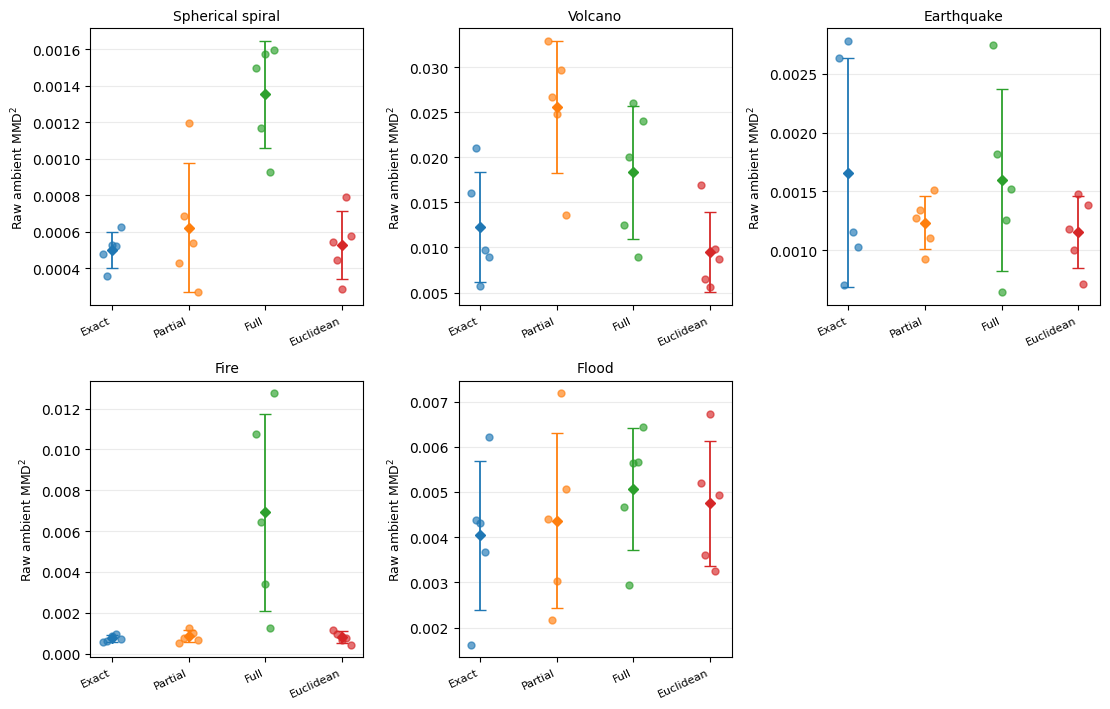

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/appendix_exports/figures/appendix_seedwise_raw_mmd_sphere.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/appendix_exports/figures/appendix_seedwise_raw_mmd_sphere.png


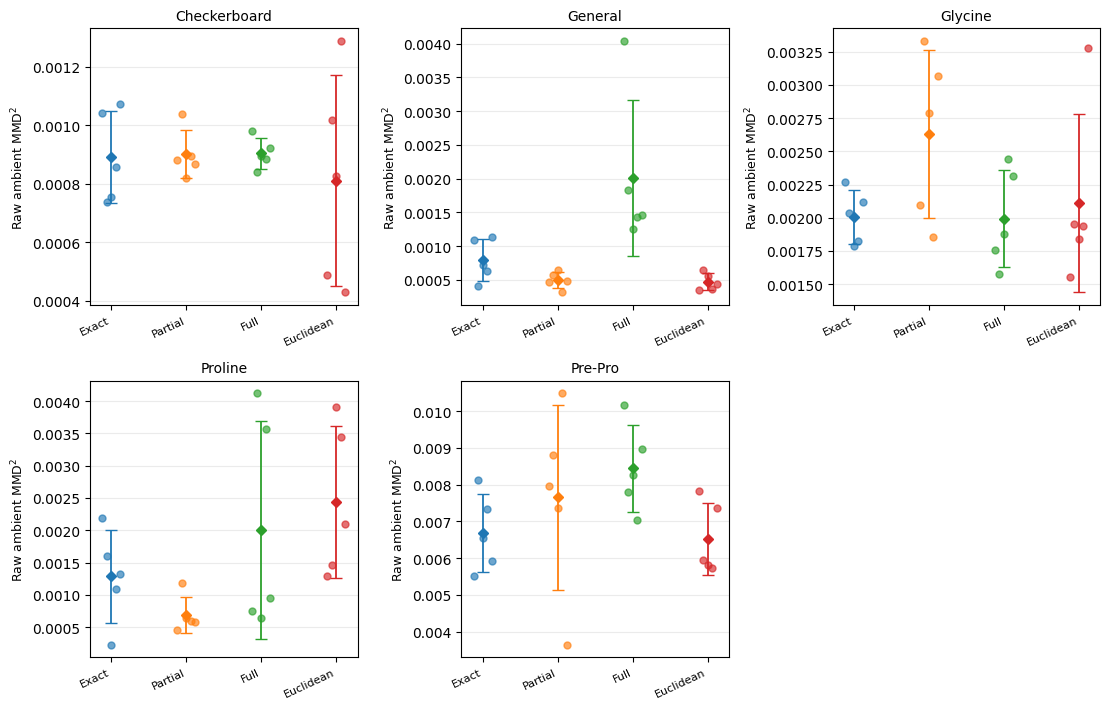

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/appendix_exports/figures/appendix_seedwise_raw_mmd_torus.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/appendix_exports/figures/appendix_seedwise_raw_mmd_torus.png


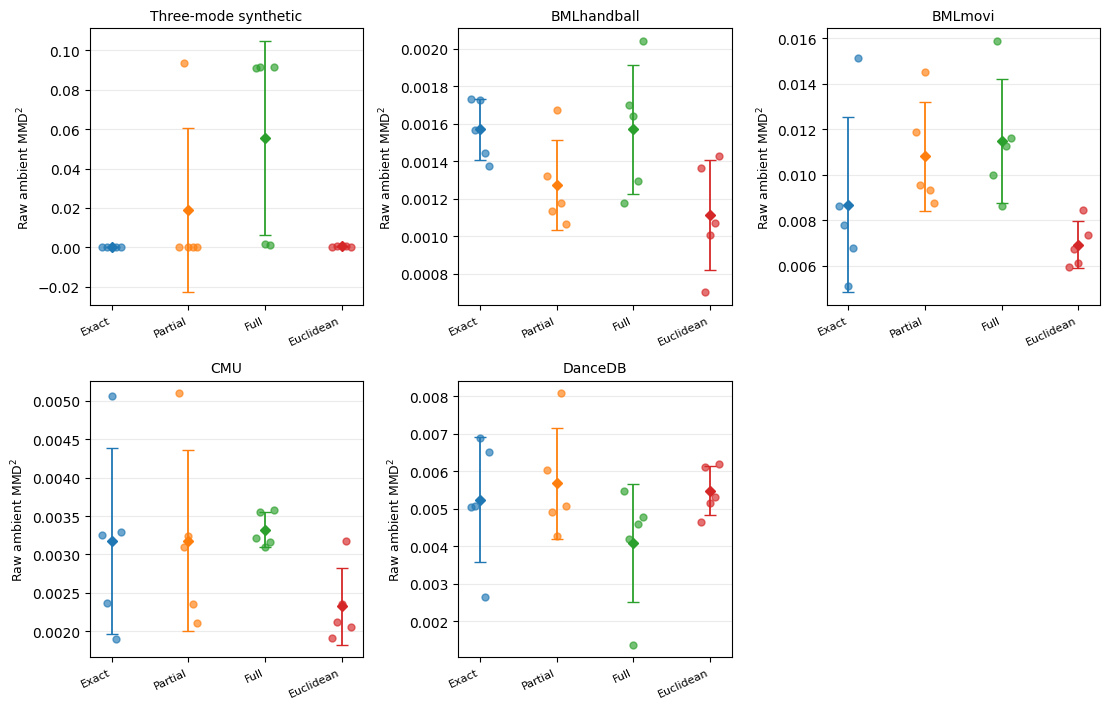

Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/appendix_exports/figures/appendix_seedwise_raw_mmd_so3.pdf
Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/appendix_exports/figures/appendix_seedwise_raw_mmd_so3.png


In [21]:
# ============================================================
# APPENDIX FIGURES: seedwise raw ambient MMD²
# One multi-panel PDF per manifold.
#
# Requires:
#   COMBINED_TEST_BY_SEED
#   COMBINED_DIR
#   METHOD_ORDER
#
# No retraining / retesting.
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

APPENDIX_FIGURE_DIR = COMBINED_DIR / "appendix_exports" / "figures"
APPENDIX_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METHOD_LABELS_APPENDIX = {
    "exact": "Exact",
    "partial": "Partial",
    "full": "Full",
    "euclidean": "Euclidean",
}

DATASET_LABELS_APPENDIX = {
    "sphere_spiral": "Spherical spiral",
    "volcano": "Volcano",
    "earthquake": "Earthquake",
    "fire": "Fire",
    "flood": "Flood",

    "torus_checkerboard": "Checkerboard",
    "general": "General",
    "glycine": "Glycine",
    "proline": "Proline",
    "pre_pro": "Pre-Pro",

    "so3_synthetic": "Three-mode synthetic",
    "BMLhandball": "BMLhandball",
    "BMLmovi": "BMLmovi",
    "CMU": "CMU",
    "DanceDB": "DanceDB",
}

DATASET_ORDER_APPENDIX = {
    "sphere": [
        "sphere_spiral",
        "volcano",
        "earthquake",
        "fire",
        "flood",
    ],
    "torus": [
        "torus_checkerboard",
        "general",
        "glycine",
        "proline",
        "pre_pro",
    ],
    "so3": [
        "so3_synthetic",
        "BMLhandball",
        "BMLmovi",
        "CMU",
        "DanceDB",
    ],
}


def plot_seedwise_manifold_appendix(manifold):

    datasets = DATASET_ORDER_APPENDIX[manifold]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(11.2, 7.2),
    )

    axes = axes.ravel()

    for ax, dataset in zip(axes, datasets):

        sub = COMBINED_TEST_BY_SEED[
            (COMBINED_TEST_BY_SEED["manifold"] == manifold)
            & (COMBINED_TEST_BY_SEED["dataset"] == dataset)
            & (COMBINED_TEST_BY_SEED["metric"] == "ambient_mmd_sq_raw")
        ].copy()

        methods = [
            m for m in METHOD_ORDER
            if m in set(sub["method"])
        ]

        all_seeds = sorted(
            sub["seed"].astype(int).unique()
        )

        offsets = np.linspace(
            -0.12,
            0.12,
            len(all_seeds),
        )

        seed_offset = dict(
            zip(all_seeds, offsets)
        )

        for x, method in enumerate(methods):

            mdf = (
                sub[sub["method"] == method]
                .sort_values("seed")
            )

            values = mdf["value"].to_numpy(float)

            mean = float(values.mean())
            sd = float(values.std(ddof=1))

            # Mean ± sample SD.
            artist = ax.errorbar(
                x,
                mean,
                yerr=sd,
                fmt="D",
                capsize=4,
                markersize=5.5,
                linewidth=1.3,
                zorder=3,
            )

            colour = artist[0].get_color()

            # Five independently trained final seeds.
            for _, row in mdf.iterrows():

                seed = int(row["seed"])

                ax.scatter(
                    x + seed_offset[seed],
                    float(row["value"]),
                    s=25,
                    color=colour,
                    alpha=0.65,
                    zorder=4,
                )

        ax.set_title(
            DATASET_LABELS_APPENDIX.get(dataset, dataset),
            fontsize=10,
        )

        ax.set_xticks(
            range(len(methods))
        )

        ax.set_xticklabels(
            [
                METHOD_LABELS_APPENDIX[m]
                for m in methods
            ],
            rotation=25,
            ha="right",
            fontsize=8,
        )

        ax.set_ylabel(
            r"Raw ambient MMD$^2$",
            fontsize=9,
        )

        ax.grid(
            axis="y",
            alpha=0.25,
        )

    # Hide unused sixth panel.
    for ax in axes[len(datasets):]:
        ax.axis("off")

    fig.tight_layout()

    pdf_path = (
        APPENDIX_FIGURE_DIR
        / f"appendix_seedwise_raw_mmd_{manifold}.pdf"
    )

    png_path = (
        APPENDIX_FIGURE_DIR
        / f"appendix_seedwise_raw_mmd_{manifold}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    fig.savefig(
        png_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print("Saved:", pdf_path)
    print("Saved:", png_path)


for manifold in ["sphere", "torus", "so3"]:
    plot_seedwise_manifold_appendix(manifold)

In [22]:
# ============================================================
# APPENDIX AUDIT: geometric drift-step cap usage
#
# IMPORTANT:
# This is NOT gradient clipping.
#
# Reads history["cap_fraction"] from the exact checkpoints
# already locked by COMBINED_RUNS.
#
# cap_fraction at a logged training step =
# fraction of the current generated batch whose proposed
# geometric displacement was capped.
#
# No training / retuning / testing.
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch

APPENDIX_TABLE_DIR = (
    COMBINED_DIR
    / "appendix_exports"
    / "tables"
)

APPENDIX_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def safe_torch_load_appendix(path):

    try:
        return torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location="cpu",
        )


cap_rows = []

for row in COMBINED_RUNS.itertuples(index=False):

    path = Path(row.checkpoint)

    if not path.exists():
        raise FileNotFoundError(path)

    saved = safe_torch_load_appendix(path)

    history = saved.get(
        "history",
        {},
    )

    cap = np.asarray(
        history.get(
            "cap_fraction",
            [],
        ),
        dtype=float,
    )

    cap = cap[
        np.isfinite(cap)
    ]

    if len(cap) == 0:
        print(
            "[missing cap history]",
            row.manifold,
            row.dataset,
            row.method,
            row.seed,
        )
        continue

    cap_rows.append({
        "manifold": row.manifold,
        "dataset": row.dataset,
        "method": row.method,
        "seed": int(row.seed),

        # Average fraction of batch samples capped
        # across logged training checkpoints.
        "mean_cap_fraction":
            float(cap.mean()),

        # Worst logged checkpoint in this run.
        "max_cap_fraction":
            float(cap.max()),

        "n_logged_checkpoints":
            int(len(cap)),
    })


CAP_BY_RUN = pd.DataFrame(
    cap_rows
)

if CAP_BY_RUN.empty:
    raise RuntimeError(
        "No history['cap_fraction'] values were found. "
        "Inspect one final checkpoint's history keys."
    )


# ------------------------------------------------------------
# Dataset × method summary across the five final seeds
# ------------------------------------------------------------

CAP_BY_CELL = (
    CAP_BY_RUN
    .groupby(
        [
            "manifold",
            "dataset",
            "method",
        ],
        as_index=False,
    )
    .agg(
        mean_cap_fraction=(
            "mean_cap_fraction",
            "mean",
        ),
        sd_mean_cap_fraction=(
            "mean_cap_fraction",
            lambda x: float(
                x.std(ddof=1)
            ),
        ),
        worst_logged_cap_fraction=(
            "max_cap_fraction",
            "max",
        ),
        n_seeds=(
            "seed",
            "nunique",
        ),
    )
)

display(
    CAP_BY_CELL.sort_values(
        "mean_cap_fraction",
        ascending=False,
    )
)


# ------------------------------------------------------------
# Compact method-level table for the appendix
# ------------------------------------------------------------

CAP_METHOD_SUMMARY = (
    CAP_BY_RUN
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        median_run_mean_cap=(
            "mean_cap_fraction",
            "median",
        ),
        max_run_mean_cap=(
            "mean_cap_fraction",
            "max",
        ),
        worst_logged_cap=(
            "max_cap_fraction",
            "max",
        ),
    )
)

METHOD_LABEL = {
    "exact": "Exact",
    "partial": "Partial",
    "full": "Full",
    "euclidean": "Euclidean",
}

METHOD_ORDER_APPENDIX = {
    "exact": 0,
    "partial": 1,
    "full": 2,
    "euclidean": 3,
}

CAP_METHOD_SUMMARY["_order"] = (
    CAP_METHOD_SUMMARY["method"]
    .map(METHOD_ORDER_APPENDIX)
)

CAP_METHOD_SUMMARY = (
    CAP_METHOD_SUMMARY
    .sort_values("_order")
    .drop(columns="_order")
)

display(CAP_METHOD_SUMMARY)


# ------------------------------------------------------------
# Save complete CSV audit
# ------------------------------------------------------------

CAP_BY_RUN.to_csv(
    APPENDIX_TABLE_DIR
    / "cap_fraction_by_final_run.csv",
    index=False,
)

CAP_BY_CELL.to_csv(
    APPENDIX_TABLE_DIR
    / "cap_fraction_by_dataset_method.csv",
    index=False,
)


# ------------------------------------------------------------
# Save compact LaTeX tabular file.
# The values are percentages.
# ------------------------------------------------------------

tex_path = (
    APPENDIX_TABLE_DIR
    / "appendix_cap_fraction.tex"
)

lines = [
    r"\begin{tabular}{lrrr}",
    r"\hline",
    (
        r"Method"
        r" & Median run mean"
        r" & Largest run mean"
        r" & Largest logged value \\"
    ),
    r"\hline",
]

for _, r in CAP_METHOD_SUMMARY.iterrows():

    lines.append(
        f"{METHOD_LABEL[r['method']]} "
        f"& {100*r['median_run_mean_cap']:.2f}\\% "
        f"& {100*r['max_run_mean_cap']:.2f}\\% "
        f"& {100*r['worst_logged_cap']:.2f}\\% "
        r"\\"
    )

lines += [
    r"\hline",
    r"\end{tabular}",
]

tex_path.write_text(
    "\n".join(lines),
    encoding="utf-8",
)

print("Saved:", tex_path)

,manifold,dataset,method,mean_cap_fraction,sd_mean_cap_fraction,worst_logged_cap_fraction,n_seeds
59,torus,torus_checkerboard,partial,0.003520,0.000458,0.941406,5
40,torus,general,euclidean,0.001994,0.000003,1.000000,5
4,so3,BMLmovi,euclidean,0.001988,0.000011,1.000000,5
6,so3,BMLmovi,full,0.001918,0.000051,0.988281,5
48,torus,pre_pro,euclidean,0.001809,0.000023,0.914062,5
7,so3,BMLmovi,partial,0.001729,0.000136,0.929688,5
18,so3,so3_synthetic,full,0.001483,0.000433,0.984375,5
43,torus,general,partial,0.001368,0.000525,0.757812,5
5,so3,BMLmovi,exact,0.001358,0.000207,0.792969,5
58,torus,torus_checkerboard,full,0.001023,0.000366,0.773438,5


,method,median_run_mean_cap,max_run_mean_cap,worst_logged_cap
1,exact,0.000125,0.001583,0.792969
3,partial,0.000156,0.004023,0.941406
2,full,0.000413,0.001973,0.988281
0,euclidean,0.000125,0.001996,1.000000


Saved: /content/drive/MyDrive/dissertation/final_four_model_all_manifolds_v1/final_combined_v3_plus_v4_exact_geodesic/appendix_exports/tables/appendix_cap_fraction.tex



## 10. Saved outputs

After a successful run, the combined directory contains:

```text
final_combined_v3_plus_v4_exact_geodesic/
├── completion_audit.csv
├── combined_test_metrics_by_seed.csv
├── combined_test_metrics_long.csv
├── combined_test_results_table_mean_sd.csv
├── dissertation_primary_results_table.csv
├── best_step_by_seed.csv
├── best_step_summary.csv
└── figures/
    ├── final_intrinsic_discrepancy.pdf
    ├── final_intrinsic_discrepancy.png
    ├── final_raw_ambient_mmd.pdf
    ├── final_raw_ambient_mmd.png
    ├── final_support_mean.pdf
    ├── final_support_mean.png
    ├── best_validation_checkpoint_step.pdf
    └── best_validation_checkpoint_step.png
```

The notebook never reads the old V3 Exact test evaluations, so the combined table cannot accidentally revert to the old Exact loss.
